# Rendu 1 — Aide Publique au Développement française
## Rapport d'exploration, de data visualisation et de pre-processing

**Dataset** : Aide publique au développement de la France (data.gouv.fr, source AFD)
**Période** : 2018 – 2024
**Variable cible** : `Engagements (K EUR)` — problème de régression

> **📋 Organisation du projet** — ce projet est structuré en deux notebooks :
> - **`Rendu1_APD_analyse.ipynb`** (ce notebook) — exploration, visualisation, pre-processing.
>   En sortie : un fichier `aide-publique-au-developpement_clean.csv` prêt pour la modélisation.
> - **`Rendu2_APD_modelisation.ipynb`** — modélisation, évaluation, interprétation.
>   En entrée : le CSV produit ci-dessus.

---

### Plan du notebook

1. **Chargement & premier aperçu** du jeu de données
2. **Exploration** : volumétrie, types, valeurs manquantes, variables clés
3. **Analyse de la variable cible** et justification de la log-transformation
4. **Pipeline de pre-processing** (7 étapes)
5. **Feature engineering** (3 features dérivées)
6. **Visualisations** (10 figures, sauvegardées dans `./figures/`)
7. **Analyses statistiques** (ANOVA, Spearman, χ²)
8. **Export** du dataset nettoyé pour le Rendu 2

> Les figures sont enregistrées sur disque pour intégration dans le rapport Word.

## 1. Setup et chargement des données

In [3]:
# Imports
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Config graphique
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.dpi'] = 110

# Chemin du fichier source (à adapter)
CSV_PATH = '/Users/augustinfaye/Documents/DataScientest/aide-publique-au-developpement.csv'
OUT_PATH = '/Users/augustinfaye/Documents/DataScientest/aide-publique-au-developpement_clean.csv'

python(76885) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(76890) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(76892) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Matplotlib is building the font cache; this may take a moment.


In [4]:
# Chargement
df = pd.read_csv(
    CSV_PATH,
    sep=';',
    encoding='utf-8-sig',
    low_memory=False
)
print(f"Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Poids en mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Dataset chargé : 106,519 lignes × 103 colonnes
Poids en mémoire : 339.9 MB


## 2. Exploration initiale

### 2.1. Aperçu des colonnes et des types

In [6]:
# Toutes les colonnes disponibles
print("Colonnes du dataset :")
for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. {col}")

Colonnes du dataset :
  1. Annee de declaration
  2. Date d'engagement
  3. Code agence
  4. Agence
  5. Num identification SNPC
  6. Numero de projet
  7. Code nature de l'activite
  8. Nature de l'activite
  9. Code du pays beneficiaire
 10. Pays beneficiaire
 11. Catégorie CAD
 12. Catégorie Banque mondiale
 13. Région
 14. Sous-région
 15. Codes ISO
 16. Code canal de transfert
 17. Canal de transfert
 18. Code canal parent
 19. Canal agrege
 20. Bi/Multi
 21. Bi/Multi.1
 22. Code type de flux
 23. Type de flux
 24. Code type de financement
 25. Type de financement
 26. Code modalite de cooperation
 27. Modalites de cooperation
 28. Description courte
 29. Code objet
 30. Objet
 31. Secteur
 32. Localisation geographique
 33. Code aide regionale aux PMA
 34. Aide regionale aux PMA
 35. Date prevue de lancement
 36. Date prevue de fin
 37. Description
 38. ODD
 39. Mots cles
 40. Genre
 41. Aide a l'environnement
 42. Gouvernance
 43. Développement du commerce
 44. Santé genesique, 

In [7]:
# Types de données
dtype_counts = df.dtypes.value_counts()
print("Répartition des types :")
print(dtype_counts)
print()
print(f"Colonnes numériques : {df.select_dtypes(include=np.number).shape[1]}")
print(f"Colonnes 'object'   : {df.select_dtypes(include='object').shape[1]}")

Répartition des types :
float64    48
object     44
int64      11
Name: count, dtype: int64

Colonnes numériques : 59
Colonnes 'object'   : 44


### 2.2. Période couverte et agences déclarantes

In [8]:
print("Années de déclaration présentes :")
print(sorted(df['Annee de declaration'].dropna().unique()))

print("\nTop 10 agences par nombre de déclarations :")
print(df['Agence'].value_counts().head(10))

Années de déclaration présentes :
[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Top 10 agences par nombre de déclarations :
Agence
Ministère des affaires étrangères                           34699
Agence française de développement                           23538
Collectivités territoriales                                 15155
Divers                                                       8878
Proparco                                                     5020
MINEFI/NATIXIS                                               3846
Ministère de l'enseignement supérieur et de la recherche     3594
Institut de recherche pour le développement (IRD)            3421
BPI France (ex. Natixis)                                     1689
MIN/EQUIPEMENT                                               1505
Name: count, dtype: int64


### 2.3. Analyse des valeurs manquantes

In [9]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct = missing_pct.sort_values(ascending=False)

print("Top 15 colonnes avec le plus de manquants :")
print(missing_pct.head(15).round(1))

print("\nColonnes entièrement renseignées (10 premières) :")
print(missing_pct[missing_pct == 0].index.tolist()[:10])

Top 15 colonnes avec le plus de manquants :
Amount of IRTC                                                                   99.9
Aide regionale aux PMA                                                           99.9
Code aide regionale aux PMA                                                      99.9
Montant garanti                                                                  99.9
PBA                                                                              99.5
Description de l'additionnalite                                                  98.9
Mots cles                                                                        98.8
Outil de mobilisation des flux prives                                            98.6
Code outil de mobilisation des flux prives                                       98.6
Code origine des fonds mobilises                                                 97.7
Origine des fonds mobilises                                                      97.7
Additionna

### 2.4. Panorama des variables catégorielles principales

In [10]:
for col in ['Type de flux', 'Type de financement', 'Bi/Multi.1',
            'Catégorie CAD', 'Région']:
    print(f"--- {col} ---")
    print(df[col].value_counts().head(8))
    print()

--- Type de flux ---
Type de flux
Aide Publique au Développement                        99503
Autre Apport du Secteur Public hors crédits-export     4450
Instruments du Secteur Privé                           1751
Non apports                                             802
Autres apports                                           13
Name: count, dtype: int64

--- Type de financement ---
Type de financement
Dons                                 86635
Prêt                                 17553
Garanties                             1329
Prise de participation                 771
Annulation/conversion de la dette      115
Obligations                             59
Rééchelonnement de la dette             57
Name: count, dtype: int64

--- Bi/Multi.1 ---
Bi/Multi.1
Bilatéral                   105239
Multilatéral                   887
Coopération triangulaire       393
Name: count, dtype: int64

--- Catégorie CAD ---
Catégorie CAD
PMA             34654
PRITI           29678
PRITS           29643

## 3. Analyse de la variable cible : `Engagements (K EUR)`

On veut prédire le montant engagé par la France sur un projet d'aide au développement.
Avant tout traitement, on examine sa distribution — critique pour le choix de la stratégie
de modélisation.

In [11]:
# Conversion numérique propre
df['Engagements (K EUR)'] = pd.to_numeric(df['Engagements (K EUR)'], errors='coerce')
target = df['Engagements (K EUR)']

print(f"Valeurs manquantes  : {target.isna().sum():,} ({target.isna().sum()/len(target)*100:.1f}%)")
print(f"Valeurs nulles (=0) : {(target == 0).sum():,}")
print(f"Valeurs négatives   : {(target < 0).sum():,}")
print(f"Valeurs > 0         : {(target > 0).sum():,}")

nonzero = target[target > 0]
print("\nStatistiques descriptives (valeurs > 0) :")
print(nonzero.describe().round(2))

print(f"\nSkewness : {nonzero.skew():.2f}")
print(f"Kurtosis : {nonzero.kurtosis():.2f}")

Valeurs manquantes  : 21,867 (20.5%)
Valeurs nulles (=0) : 7,559
Valeurs négatives   : 2
Valeurs > 0         : 77,091

Statistiques descriptives (valeurs > 0) :
count      77091.00
mean        1830.88
std        30706.99
min            0.00
25%            5.00
50%           15.18
75%          135.34
max      3817719.41
Name: Engagements (K EUR), dtype: float64

Skewness : 76.34
Kurtosis : 7624.10


In [12]:
# Quantiles étendus pour illustrer la concentration
print("Distribution détaillée :")
for q in [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999]:
    print(f"  Q{q*100:>5.1f}% = {nonzero.quantile(q):>14,.2f} K EUR")

Distribution détaillée :
  Q  1.0% =           0.10 K EUR
  Q  5.0% =           0.61 K EUR
  Q 10.0% =           1.42 K EUR
  Q 25.0% =           5.00 K EUR
  Q 50.0% =          15.18 K EUR
  Q 75.0% =         135.34 K EUR
  Q 90.0% =         706.38 K EUR
  Q 95.0% =       2,199.54 K EUR
  Q 99.0% =      35,000.00 K EUR
  Q 99.9% =     200,000.00 K EUR


**Observation** : distribution extrêmement asymétrique — médiane à ~15 K EUR,
mais 99ᵉ percentile à 35 000 K EUR et maximum à 3,8 Md EUR. Le rapport médiane / moyenne
vaut environ 120, symptomatique d'une concentration massive des volumes sur quelques
très gros projets.

**Décision** : appliquer une transformation `log(1 + x)` qui réduit la skewness de 76,3 à ~0,96
et rend la cible exploitable par la plupart des modèles.

In [13]:
# Log-transformation de la cible
log_target = np.log1p(nonzero)
print(f"Skewness brut : {nonzero.skew():.2f}")
print(f"Skewness log  : {log_target.skew():.2f}")
print(f"Kurtosis brut : {nonzero.kurtosis():.2f}")
print(f"Kurtosis log  : {log_target.kurtosis():.2f}")

# Test de normalité D'Agostino
sample = nonzero.sample(5000, random_state=42)
k2_raw, p_raw = stats.normaltest(sample)
k2_log, p_log = stats.normaltest(np.log1p(sample))
print(f"\nTest D'Agostino (n=5000) :")
print(f"  Avant log : K²={k2_raw:.1f}, p={p_raw:.2e}")
print(f"  Après log : K²={k2_log:.1f}, p={p_log:.2e}")

Skewness brut : 76.34
Skewness log  : 0.96
Kurtosis brut : 7624.10
Kurtosis log  : 0.75

Test D'Agostino (n=5000) :
  Avant log : K²=15273.1, p=0.00e+00
  Après log : K²=624.4, p=2.60e-136


## 4. Pipeline de pre-processing

Le pipeline est organisé en 6 étapes. À chaque étape, on affiche l'effet sur les dimensions
du dataset pour garder une trace reproductible.

In [14]:



# On repart du CSV brut pour que le notebook soit rejouable depuis n'importe quel point
df = pd.read_csv(CSV_PATH, sep=';', encoding='utf-8-sig', low_memory=False)
print(f"[0] Dataset initial : {df.shape}")

[0] Dataset initial : (106519, 103)


### Étape 1 — Harmonisation des types de colonnes

Le CSV chargé par `read_csv` ne distingue pas toujours correctement les types : les
colonnes de dates sont lues comme des chaînes de caractères, les montants avec le format
français (virgule décimale, espace comme séparateur de milliers) sont aussi lus comme
des chaînes. On force explicitement les bons types **avant toute autre étape**, sinon
les filtres numériques (`> 0`), les imputations (`fillna(0)`), et les features dérivées
des dates ne peuvent pas fonctionner. Cette étape se fait une fois pour toutes en début
de pipeline ; tous les traitements suivants peuvent alors présupposer des types propres.

On en profite pour normaliser également les colonnes de type texte : apostrophes courbes
(Unicode `\u2019`) remplacées par l'apostrophe droite, espaces de début/fin supprimés,
espaces internes multiples collapsés en un seul. Cette normalisation est un pré-requis
technique indispensable à l'étape 7 (harmonisation des libellés catégoriels), dont les
dictionnaires de fusion utilisent l'apostrophe droite — sans ce nettoyage préalable,
une chaîne comme « l'économie » (apostrophe courbe) ne matcherait pas « l'économie »
(apostrophe droite) et le remplacement serait silencieusement ignoré.

In [15]:
# --- Colonnes dates ---
DATE_COLS = [
    "Date d'engagement",
    'Date prevue de lancement',
    'Date prevue de fin',
    'Date de premier remboursement',
    'Date finale de remboursement ou echeance attendue pour les actions',
]
for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
        print(f"✅ {col} → datetime")

# --- Colonnes numériques (montants K/M EUR/USD) ---
# Le CSV utilise le format français (virgule décimale, espace comme séparateur)
# qu'on normalise avant d'appeler pd.to_numeric.
montant_cols = [c for c in df.columns
                if any(kw in c for kw in ['K EUR', 'K USD', 'M EUR', 'M USD'])]

for col in montant_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .str.replace(' ', '',  regex=False)
        .replace('nan', np.nan)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Année ---
if 'Annee de declaration' in df.columns:
    df['Annee de declaration'] = pd.to_numeric(
        df['Annee de declaration'], errors='coerce'
    ).astype('Int64')

print("\nConversions de types terminées.")
print(df.dtypes.value_counts())


# --- Colonnes texte : apostrophes, espaces parasites ---
# Après les conversions ci-dessus, seules les VRAIES colonnes texte restent en dtype 'object'.
# On les normalise pour éviter les faux-négatifs dans les étapes de remplacement (étape 7).
str_cols = df.select_dtypes(include='object').columns

for col in str_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('\u2019', "'", regex=False)    # apostrophe courbe → droite
        .str.strip()                                 # espaces début/fin
        .str.replace(r'\s+', ' ', regex=True)        # espaces internes multiples
        .replace('nan', pd.NA)
    )

print(f"\n✅ {len(str_cols)} colonnes texte normalisées")

✅ Date d'engagement → datetime
✅ Date prevue de lancement → datetime
✅ Date prevue de fin → datetime
✅ Date de premier remboursement → datetime
✅ Date finale de remboursement ou echeance attendue pour les actions → datetime

Conversions de types terminées.
float64           48
object            39
int64             10
datetime64[ns]     5
Int64              1
Name: count, dtype: int64

✅ 39 colonnes texte normalisées


### Étape 2 — Suppression des colonnes redondantes

- Les montants en USD (on garde les EUR, unité naturelle pour la France)
- Les montants en M EUR quand le K EUR existe
- Les codes numériques des nomenclatures quand le libellé existe (plus interprétable)

In [16]:
# Montants en USD
cols_usd = [c for c in df.columns if '(K USD)' in c]
df = df.drop(columns=cols_usd)
print(f"Supprimé {len(cols_usd)} colonnes USD")

# M EUR redondants
df = df.drop(columns=['Montant versé (M EUR)', 'Équivalent don (M EUR)'])

# Codes redondants (le libellé est conservé)
codes_redondants = [
    'Code agence', "Code nature de l'activite", 'Code du pays beneficiaire',
    'Code canal de transfert', 'Code canal parent', 'Bi/Multi',
    'Code type de flux', 'Code type de financement',
    'Code modalite de cooperation', 'Code objet',
    'Code aide regionale aux PMA', 'Code outil de mobilisation des flux prives',
    'Code origine des fonds mobilises', 'Code profil de remboursement',
    'Code Marqueur ISP', 'code secteur CAD'
]
df = df.drop(columns=[c for c in codes_redondants if c in df.columns])
print(f"Après suppression des colonnes codes : {df.shape}")

# Identifiants techniques non exploitables en ML classique
identifiants = ['Numero de projet', 'Codes ISO']
df = df.drop(columns=[c for c in identifiants if c in df.columns])
print(f"Après suppression des colonnes identifiants : {df.shape}")

# textes verbose non exploitable pour notre modèle
descriptions = [
    'Description courte',
    'Description',
    'Mots cles',
    "Description de l'additionnalite",
    'Additionnalite - objectif de développement',
    #'Marqueurs'
]
df = df.drop(columns=[c for c in descriptions if c in df.columns])
print(f"Après suppression des colonnes description : {df.shape}")

#Colonnes dates non pertinentes pour la prédiction dans notre cas 
DATE_COLS = [
    'Année de déclaration',
    #"Date d'engagement", #on la garde pour la detection de doublons
    'Date prevue de lancement',
    'Date prevue de fin',
    'Date de premier remboursement',
    'Date finale de remboursement ou echeance attendue pour les actions',
]
df = df.drop(columns=[c for c in DATE_COLS if c in df.columns])
print(f"Après suppression des colonnes dates : {df.shape}")

# champs peu pertinants pour la prédiction
colonnes_inutiles=[
    'Localisation geographique',
    'Type de finance mixte'
]    
df = df.drop(columns=[c for c in colonnes_inutiles if c in df.columns])
print(f"Après suppression des colonnes inutiles : {df.shape}")

Supprimé 8 colonnes USD
Après suppression des colonnes codes : (106519, 77)
Après suppression des colonnes identifiants : (106519, 75)
Après suppression des colonnes description : (106519, 70)
Après suppression des colonnes dates : (106519, 66)
Après suppression des colonnes inutiles : (106519, 64)


In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106519 entries, 0 to 106518
Data columns (total 64 columns):
 #   Column                                                                         Non-Null Count   Dtype         
---  ------                                                                         --------------   -----         
 0   Annee de declaration                                                           106519 non-null  Int64         
 1   Date d'engagement                                                              106516 non-null  datetime64[ns]
 2   Agence                                                                         106519 non-null  object        
 3   Num identification SNPC                                                        106519 non-null  object        
 4   Nature de l'activite                                                           106519 non-null  object        
 5   Pays beneficiaire                                                       

### Étape 3 — Imputation et nettoyage de la variable cible

On procède en deux temps : **d'abord une imputation** des engagements manquants en
exploitant deux règles métier dérivées des champs auxiliaires du dataset ; **ensuite
le nettoyage** des lignes qui restent avec une cible manquante ou aberrante après
imputation. Cette séquence permet de récupérer un maximum d'observations exploitables
avant le filtrage.

**Règle 1** — Pour les déclarations dont la `Nature de l'activite` est
`"Activité nouvellement notifiée"` ou `"Engagement dérivé du versement"`, l'engagement
peut être dérivé du `Montant perçu`. C'est particulièrement logique pour
`"Engagement dérivé du versement"` — le libellé lui-même indique que l'engagement suit
le versement. On impute donc les engagements manquants de ces lignes par le montant
perçu (si renseigné).

**Règle 2** — Pour les projets de type « pure don », le `Montant versé` est égal à
l'`Équivalent don` (le financement est un don simple sans composante prêt).
Dans ces cas, si l'engagement est manquant, on le remplit avec l'équivalent-don
(qui en l'occurrence est aussi égal au montant versé).

Après ces deux règles, on filtre les lignes résiduelles à cible NA ou ≤ 0 (annulations,
reporting sans engagement nouveau).

In [18]:
# ====================================================================
# ÉTAPE 4a : Imputation de la cible par des règles métier
# ====================================================================
# Avant de filtrer les lignes à cible manquante, on récupère autant
# d'informations que possible à partir des champs auxiliaires du dataset.

na_before = df["Engagements (K EUR)"].isna().sum()
print(f"[4a] Engagements manquants avant imputation : {na_before:,}")


# --- Règle 1 : Nature "Activité nouvellement notifiée" ou "Engagement dérivé du versement" ---
# Pour ces déclarations, l'engagement peut être dérivé du montant perçu.
# Cas particulier : "Engagement dérivé du versement" — le nom même indique l'opération.
mask_rule1 = (
    df["Nature de l'activite"].isin(
        ["Activité nouvellement notifiée", "Engagement dérivé du versement"]
    )
    & df["Engagements (K EUR)"].isna()
    & df["Montant percu (K EUR)"].notna()
)
n_rule1 = mask_rule1.sum()
df.loc[mask_rule1, "Engagements (K EUR)"] = df.loc[mask_rule1, "Montant percu (K EUR)"]
print(f"[4a] Règle 1 (Nature + Montant perçu) : {n_rule1:,} lignes récupérées")


# --- Règle 2 : "Pure don" (Montant versé == Équivalent don) ---
# Si le financement est un don simple et que l'engagement manque, on le remplit
# avec l'équivalent-don (qui égale le montant versé par définition d'un pure don).
mask_rule2 = (
    (df["Montant verse (K EUR)"] == df["Equivalent don (K EUR)"])
    & df["Engagements (K EUR)"].isna()
    & df["Equivalent don (K EUR)"].notna()
)
n_rule2 = mask_rule2.sum()
df.loc[mask_rule2, "Engagements (K EUR)"] = df.loc[mask_rule2, "Equivalent don (K EUR)"]
print(f"[4a] Règle 2 (Pure don = Équivalent don) : {n_rule2:,} lignes récupérées")

na_after = df["Engagements (K EUR)"].isna().sum()
print(f"[4a] Engagements manquants après imputation : {na_after:,} "
      f"(total récupéré : {na_before - na_after:,})")


# ====================================================================
# ÉTAPE 4b : Filtrage des lignes résiduelles à cible manquante ou ≤ 0
# ====================================================================
avant = len(df)
df = df[df["Engagements (K EUR)"].notna()]
print(f"\n[4b] Lignes supprimées (cible NA résiduelle) : {avant - len(df):,}")

avant = len(df)
df = df[df["Engagements (K EUR)"] > 0]
print(f"[4c] Lignes supprimées (cible <= 0) : {avant - len(df):,}")

print(f"\n[4] Après imputation + nettoyage : {df.shape}")

[4a] Engagements manquants avant imputation : 21,867
[4a] Règle 1 (Nature + Montant perçu) : 98 lignes récupérées
[4a] Règle 2 (Pure don = Équivalent don) : 6,562 lignes récupérées
[4a] Engagements manquants après imputation : 15,207 (total récupéré : 6,660)

[4b] Lignes supprimées (cible NA résiduelle) : 15,207
[4c] Lignes supprimées (cible <= 0) : 7,563

[4] Après imputation + nettoyage : (83749, 64)


### Étape 4 — Suppression des doublons

Suppression des doublons :
 - même date d'engagement + même montant : doublon parfait -> on drop
 - date d'engagement et montant différent : on additionne les montants et on garde la première date

In [19]:
#  On garde en mémoire le nombre initial de lignes
nb_initial = len(df)

# Suppression des doublons parfaits
df = df.drop_duplicates(subset=["Date d'engagement", "Engagements (K EUR)", "Num identification SNPC"])

#affichage du nombre de lignes après suppression des doublons
nb_apres_suppression_doublons = len(df)
print(f"Nombre de doublons parfait supprimées: {nb_initial - nb_apres_suppression_doublons}")

# Calcul de la somme cumulée par identifiant
df["Engagements (K EUR)"] = df.groupby("Num identification SNPC")["Engagements (K EUR)"].transform("sum")

# Tri par date pour identifier la plus ancienne
df = df.sort_values(by=["Num identification SNPC", "Date d'engagement"])

# Suppression des lignes redondantes pour ne garder que la ligne agrégée
df = df.drop_duplicates(subset=["Num identification SNPC"], keep="first")

# Affichage du résultat
nb_final = len(df)
print(f"Nombre de lignes supprimées : {nb_initial - nb_final}")

# CLEANUP COLONNES: 
# Identifiants techniques non exploitables en ML classique
identifiants = ['Num identification SNPC', "Date d'engagement"]
df = df.drop(columns=[c for c in identifiants if c in df.columns])
print(f"Après suppression des colonnes identifiants : {df.shape}")

# Suppression des Montants (risque de data leakage)
colonnes_montants = [
    'Montant non lie (K EUR)',
    'Montant lie (K EUR)',
    'Montant verse (K EUR)',
    'Equivalent don (K EUR)'
]
df = df.drop(columns=[c for c in colonnes_montants if c in df.columns])
print(f"Après suppression des colonnes montants : {df.shape}")


Nombre de doublons parfait supprimées: 254
Nombre de lignes supprimées : 4724
Après suppression des colonnes identifiants : (79025, 62)
Après suppression des colonnes montants : (79025, 58)


### Étape 5 — Suppression des colonnes > 90 % NA

Ces colonnes correspondent pour l'essentiel au bloc « instruments financiers complexes »
(flux privés mobilisés, additionnalité, calendriers de remboursement, taux) qui n'est
renseigné que pour une petite minorité de projets.

In [20]:
missing_pct = (df.isna().sum() / len(df)) * 100
cols_to_drop = missing_pct[missing_pct > 90].index.tolist()
print(f"Colonnes supprimées (> 90% NA) : {len(cols_to_drop)}")
for c in cols_to_drop:
    print(f"  - {c} ({missing_pct[c]:.1f}% NA)")

df = df.drop(columns=cols_to_drop)

print(f"\n[5] Après suppression colonnes creuses : {df.shape}")

Colonnes supprimées (> 90% NA) : 20
  - Aide regionale aux PMA (99.9% NA)
  - PBA (99.4% NA)
  - Investissement (90.5% NA)
  - Montant percu (K EUR) (96.5% NA)
  - Montant partiellement lie (K EUR) (96.0% NA)
  - Amount of IRTC (99.9% NA)
  - Outil de mobilisation des flux prives (98.4% NA)
  - Montants des flux prives mobilises (K EUR) (96.6% NA)
  - Origine des fonds mobilises (97.6% NA)
  - Profil de remboursement (98.0% NA)
  - Nombre de remboursements par annee (97.8% NA)
  - Taux d interet ou rendement attendu pour les actions (98.6% NA)
  - Deuxieme taux d interet (equivalent taux fixe pour les prets a taux variable) (99.4% NA)
  - Interets ou dividendes recus (K EUR) (97.4% NA)
  - Principal debourse et restant à payer (K EUR) (98.9% NA)
  - Arrieres de principal (K EUR) (99.5% NA)
  - Arrieres du taux d interet (K EUR) (99.4% NA)
  - Montant garanti (99.9% NA)
  - Marqueur ISP (98.2% NA)
  - Type d'additionnalite (99.2% NA)

[5] Après suppression colonnes creuses : (79025, 38)

In [21]:
df.isna().sum().sort_values(ascending=False).head(41)

Développement du commerce                                      70421
Priorité CICID                                                 61391
Marqueurs                                                      57102
FTC                                                            45322
Santé genesique, maternelle, neonatale et infantile (SGMNI)    41692
Inclusion des personnes en situation de handicap               39523
Reduction du risque de catastrophe                             36782
Nutrition                                                      36154
Desertification                                                34526
Biodiversite                                                   31961
Attenuation du changement climatique                           31754
Adaptation au changement climatique                            31515
Gouvernance                                                    28520
Aide a l'environnement                                         27553
Genre                             

### Étape 6 — Transformation de la cible

In [22]:
df['log_engagements'] = np.log1p(df['Engagements (K EUR)'])
print(f"[5] Cible log créée")
print(f"    Skewness brut : {df['Engagements (K EUR)'].skew():.2f}")
print(f"    Skewness log  : {df['log_engagements'].skew():.2f}")

[5] Cible log créée
    Skewness brut : 71.98
    Skewness log  : 0.92


### Étape 7 — Correction et harmonisation des marqueurs politiques

Les marqueurs politiques (Genre, Climat, Biodiversité, etc.) suivent normalement le
barème CAD-OCDE 0/1/2 (non concerné / objectif significatif / objectif principal).
Deux corrections sont nécessaires :

- **Valeurs hors-barème** : pour quelques marqueurs (Désertification, SGMNI), le
  référentiel a été révisé par l'OCDE et certaines valeurs historiques (3, 4) ne sont
  plus valides. On les remplace par le mode des codes valides.
- **Type de stockage** : on convertit en `Int64` nullable (entier qui supporte les NaN)
  pour garder la modalité « non renseigné » comme une information distincte. **On
  n'impute pas par -1** : un nombre négatif induirait un faux ordre dans les modèles
  linéaires (« non renseigné < non concerné < objectif »), ce qui est sémantiquement
  faux. Le `OneHotEncoder` du rendu 2 traitera naturellement le NaN comme une modalité
  distincte des valeurs 0, 1, 2.

In [23]:
# Correction des marqueurs dont la nomenclature CAD-OCDE a été modifiée
# dans une révision récente : certaines valeurs historiques ne font plus
# partie du référentiel officiel.
#  - Desertification : ancien barème 0-3, nouveau barème 0-2
#  - SGMNI           : ancien barème 0-4, nouveau barème 0-2
# On remplace les valeurs hors-barème par le mode (valeur la plus fréquente
# des codes valides).
marqueurs_revises = {
    'Desertification':                                              [0, 1, 2],
    'Santé genesique, maternelle, neonatale et infantile (SGMNI)':  [0, 1, 2],
}
for col, codes_valides in marqueurs_revises.items():
    if col in df.columns:
        vals_numeric = pd.to_numeric(df[col], errors='coerce')
        hors_bareme = ~vals_numeric.isin(codes_valides) & vals_numeric.notna()
        n_corr = hors_bareme.sum()
        if n_corr > 0:
            mode_val = vals_numeric[vals_numeric.isin(codes_valides)].mode().iloc[0]
            df.loc[hors_bareme, col] = mode_val
            print(f"  {col[:50]:52s} : {n_corr} valeurs hors-barème → {int(mode_val)} (mode)")


# Marqueurs politiques : conversion en Int64 nullable (entier qui supporte les NaN).
# On NE remplace PAS les NaN par -1 : cela induirait un ordre artificiel dans les
# modèles linéaires (NaN < 0 < 1 < 2). Le NaN reste tel quel et sera traité au
# rendu 2 par OneHotEncoder, qui en fera une modalité distincte au même titre que
# les valeurs 0, 1, 2.
marqueurs = [
    'Genre', "Aide a l'environnement", 'Gouvernance', 'Développement du commerce',
    'Santé genesique, maternelle, neonatale et infantile (SGMNI)',
    'Reduction du risque de catastrophe', 'Nutrition',
    'Inclusion des personnes en situation de handicap', 'Biodiversite',
    'Attenuation du changement climatique', 'Adaptation au changement climatique',
    'Desertification', 'Investissement', 'FTC'
]
for c in marqueurs:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce').astype('Int64')

print(f"[6] Marqueurs harmonisés. Dimensions : {df.shape}")

  Desertification                                      : 2 valeurs hors-barème → 0 (mode)
  Santé genesique, maternelle, neonatale et infantil   : 109 valeurs hors-barème → 0 (mode)
[6] Marqueurs harmonisés. Dimensions : (79025, 39)


### Étape 8 — Harmonisation des libellés catégoriels

Les colonnes catégorielles contiennent des doublons dus à la saisie : variations de casse
(`RÉSEAU` / `Réseaux` / `Réseau`), fautes de frappe (`Gouvernment` au lieu de `Gouvernement`,
`oopération` au lieu de `coopération`), mélange de langues FR/EN (`Other public entities in
donor country` / `Autres entité publique dans le pays donneur`) et libellés CAD qui ont
évolué dans le temps (changement de nomenclature par l'OCDE). On normalise ces libellés
avant toute étape dépendant des fréquences (notamment le regroupement des modalités rares
qui suit), sinon les variantes d'un même libellé sont comptées séparément et risquent de
basculer à tort dans la modalité générique « Autre ».

Cette étape repose sur un travail d'inventaire manuel des valeurs uniques de chaque colonne,
qui n'est pas automatisable de manière fiable — un outil de matching approximatif (fuzzy
matching, distance de Levenshtein) introduirait des faux positifs métier (par exemple
confondre « Agence française de développement » avec « Agence française pour le
développement international », qui sont deux entités distinctes).

In [24]:
# --- Canal de transfert : typos, casse, FR/EN, libellés CAD tronqués ---
fusions_canal = {

    # --- Typo France ----
    'Cités Unies Frances': 'Cités Unies France',

    # --- Typo "Gouvernment" (e manquant) ---
    'Gouvernment central': 'Gouvernement central',
    'Central Government':  'Gouvernement central',
    'Gouvernment local':   'Gouvernement local',

    # --- ONG internationale (casse + pluriel) ---
    'ONG INTERNATIONALE':  'ONG internationale',
    'ONG internationales': 'ONG internationale',

    # --- Entité publique pays donneur ---
    'Autres entité publique dans le pays donneur': 'Autre entité publique dans le pays donneur',
    'Other public entities in donor country': 'Autre entité publique dans le pays donneur',

    # --- Entité publique pays bénéficiaire ---
    'Autre entité publique dans le pays bénéficiaire': 'Autres entité publique dans le pays bénéficiaire',

    # --- Institutions secteur privé ---
    'Institutions du Secteur Privé': 'Institutions du secteur privé',

    # --- OSCE : faute de frappe "oopération" ---
    "Organisation pour la sécurité et la oopération en Europe": "Organisation pour la sécurité et la coopération en Europe",

    # --- Réseau ---
    'Réseaux': 'Réseau',
    'RÉSEAU':  'Réseau',

    # --- Université / instituts (libellé reformulé CAD) ---
    "Université, collège ou autre établissement d'enseignement, institut de recherche ou de réflexion":
        "Université, institut d'éducation et autre institution d'enseignement, institut de recherche ou groupe de réflexion",

    # --- Département opérations de paix ONU (libellé tronqué) ---
    "Département des opérations de paix des Nations unies. Opérations de maintien de la paix [seulement MINURSO,MINUSCA,MINUSMA, MINUSTAH,MONUSCO,MINUAD, FINUL,FISNUA,MINUK, MINUL,UNMISS,ONUCI]. Notifier les contributions mission par mission au format SNPC++":
        "Département des opérations de paix des Nations unies. Opérations de maintien de la paix [seulement MINURSO,MINUSCA,MINUSMA, MINUSTAH,MONUSCO,MINUAD, FINUL,FISNUA,MINUK, MINUL,UNMISS,ONUCI]. Notifier les contributions mission par mission au format SNPC++.",
    "Département des opérations de paix des Nations unies. Opérations de maintien de la paix [seulement MINURSO,MINUSCA,MINUSMA, MINUSTAH,MONUSCO,MINUAD, FINUL,FISNUA,MINUK, MINUL,UNMISS,ONUCI]. Notifier l":
        "Département des opérations de paix des Nations unies. Opérations de maintien de la paix [seulement MINURSO,MINUSCA,MINUSMA, MINUSTAH,MONUSCO,MINUAD, FINUL,FISNUA,MINUK, MINUL,UNMISS,ONUCI]. Notifier les contributions mission par mission au format SNPC++.",

    # --- Agence Nations Unies (NU vs ONU) ---
    "Agence, fonds ou commission des Nations Unies (ONU)": "Agence, fonds ou commission des Nations unies (NU)",

    # --- Fonds multilatéral Protocole de Montréal (avec/sans sigle) ---
    "Fonds multilatéral pour l'application du Protocole de Montréal (FMPM)":
        "Fonds multilatéral pour l'application du Protocole de Montréal",

    # --- Coalition innovations / préparation aux épidémies (libellé tronqué) ---
    "Coalition pour les innovations en matière de préparation":
        "Coalition pour les innovations en matière de préparation aux épidémies",

    # --- UICN (version anglaise) ---
    'INTERNATIONAL UNION FOR CONSERVATION OF NATURE': 'Union internationale pour la conservation de la nature',

    # --- Action contre la faim (variantes linguistiques + entités pays) ---
    'ACTION AGAINST HUNGER': 'Action contre la faim',
    'ACTION CONTRE LA FAIM': 'Action contre la faim',
    'ACTION CONTRE LA FAIM Espagne': 'Action contre la faim',
    'Fundacion Accion contra el hambre': 'Action contre la faim',

    # --- optionnelles ---
    # 'Mercy Corps Europe': 'Mercy Corps',
}

n_before = df['Canal de transfert'].nunique()
df['Canal de transfert'] = df['Canal de transfert'].replace(fusions_canal)
n_after = df['Canal de transfert'].nunique()
print(f"Canal de transfert : {n_before} modalités → {n_after} (-{n_before-n_after})")

# Suppression de l'entrée parasite (question saisie comme valeur)
#PARASITE = "Est-ce que vous avez le nom de l'ONG internationale?"
#n_before = len(df)
#df = df[df['Canal de transfert'] != PARASITE]
#print(f"Lignes supprimées (entrée parasite) : {n_before - len(df)}")


# --- Agence : libellés qui ont évolué dans le temps (renommages administratifs) ---
df['Agence'] = df['Agence'].replace({
    "Ministère de l'enseignement supérieur et de la recherche (MESR)":
        "Ministère de l'enseignement supérieur et de la recherche",
    "Ministère de l'économie et des finances":
        "Ministère de l'économie, des finances, et de la souveraineté industrielle"
})


# --- Canal agrege : harmonisation de la casse ---
df['Canal agrege'] = df['Canal agrege'].replace({
    "Agence, fonds ou commission des Nations Unies (NU)": "Agence, fonds ou commission des Nations unies (NU)",
    "Groupe de la Banque Mondiale (BM)":                  "Groupe de la Banque mondiale (BM)",
    "Fonds Monétaire International (FMI)":                "Fonds monétaire international (FMI)",
})


# --- Pays beneficiaire : Türkiye (nom officiel ONU depuis 2022) → Turquie (usage FR) ---
df['Pays beneficiaire'] = df['Pays beneficiaire'].replace({
    "Türkiye": "Turquie",
})


# --- Origine des fonds mobilises : capitalisation homogène ---
if 'Origine des fonds mobilises' in df.columns:
    df['Origine des fonds mobilises'] = (
        df['Origine des fonds mobilises'].str.capitalize()
    )


# --- Objet : fusions de libellés CAD (nomenclature mise à jour par l'OCDE) ---
df['Objet'] = df['Objet'].replace({
    "Approvisionnement en eau potable et assainissement - dispositifs de base":
        "Approvisionnement en eau potable – dispositifs de base",
    "Approvisionnement en eau – systèmes à grande échelle":
        "Approvisionnement en eau et assainissement - systèmes à grande échelle",
    "Radio, télévision, presse écrite":
        "Radio, télévision, médias imprimés et en ligne",
    "Business development services":
        "Services pour le développement des entreprises",
    "Politique commerciale et administration":
        "Politique commerciale et gestion administrative"
})

# --- Localisation geographique : harmonisation par mise en majuscules ---
# Cette colonne contient ~970 modalités, dont 132 groupes de variantes de casse
# résolubles à 100% par un simple upper() (ex: 'Maroc' / 'MAROC', 'Algérie' / 'ALGERIE').
# Test : 971 uniques → 836 après upper (-135 doublons), gain suffisant
# sans avoir à gérer la normalisation des accents. Les valeurs composites "Pays1, Pays2" sont aussi
# mises en majuscules : cohérent et idempotent.
#n_before = df['Localisation geographique'].nunique()

# (1) Cas particuliers : typos, reformulations, inversions d'ordre
#fusions_loc = {
#    "COTE D IVOIRE":                          "Côte d'Ivoire",
#    "Republique DDémocratique du Congo":      "République démocratique du Congo",
#    "REPUBLIQUE DEMOCRATIQUE DU CONGO.":      "République démocratique du Congo",
#    "République democratique du congo":       "République démocratique du Congo",
#    "CENTRAFRICAINE, REPUBLIQUE":             "République centrafricaine",
#    "LAOS, REPUBLIQUE DEMOCRATIQUE POPULAIRE": "Laos",
#    "Vietnam":                                "Viet Nam",
#    "VIETNAM":                                "Viet Nam",
#    "CONGO  BRAZZAVILLE":                     "Congo",
#    "Multilateral":                           "Multilatéral",
#    "Hanoï":                                  "Hanoi",
#    "HaÏti":                                  "Haïti",
#    "HAÏTI":                                  "Haïti",
#    "Éthiopie":                               "Ethiopie",
#}
#df['Localisation geographique'] = df['Localisation geographique'].replace(fusions_loc)

#df['Localisation geographique'] = df['Localisation geographique'].str.upper()
#n_after = df['Localisation geographique'].nunique()
#print(f"Localisation géographique : {n_before} modalités → {n_after} "
#      f"(-{n_before - n_after} doublons de casse fusionnés)")


print("✅ Fusions appliquées sur toutes les colonnes")

Canal de transfert : 570 modalités → 547 (-23)
✅ Fusions appliquées sur toutes les colonnes


### Étape 9 — Suppression des variables non exploitables

Une étude empirique préalable (taux de NA, corrélation log-log avec la cible,
pourcentage de lignes où la colonne est strictement égale à la cible) a été menée
sur les variables monétaires connexes du dataset. Le détail de cette étude figure
dans le rapport (§2.3) et confirme le verdict ci-dessous. Pour garder le notebook
concis et focalisé sur le pipeline de production, l'étude statistique elle-même
n'est pas réexécutée ici — on applique directement les conclusions.

**Verdict pour les colonnes monétaires restantes** : toutes supprimées.

> Note : quatre colonnes monétaires (Versé, Don, Non lié, Lié) ont déjà été retirées
> à l'étape 4 (suppression des doublons) car elles étaient nécessaires au calcul
> d'agrégation mais constituent un risque de leakage. Les cinq restantes sont supprimées
> ici pour les motifs suivants :

1. **Leakage indirect** (Perçu) — utilisé dans l'imputation de la cible à l'étape 3,
   86 % de NA.
2. **Trop creuses** (Partiellement lié à 92 %, Flux privés mobilisés à 91 %,
   Garanti à 99,9 %).
3. **Variance nulle** (Monnaie) — une seule modalité (code 918, l'euro).

**Suppression supplémentaire de 10 autres colonnes**, justifiée métier :

| Colonne | Motif |
|---|---|
| `map_code` | Doublon avec `Pays beneficiaire` |
| `Annee de declaration` | Variable non explicative ; pas de tendance temporelle exploitable au niveau projet |
| `Localisation geographique` | Valeurs inconsistantes (mélange noms de pays, villes, coordonnées GPS) |
| `Date prevue de lancement` | ~65 % de NA |
| `Date prevue de fin` | ~65 % de NA |
| `Date de premier remboursement` | 88,7 % de NA — variable post-exécution (prêts uniquement) |
| `Date finale de remboursement ou echeance attendue pour les actions` | 84,1 % de NA — post-exécution |
| `ODD` | Redondant avec `nb_ODD` (feature dérivée) |
| `ODD Agrégé` | Idem |
| `Type de finance mixte` | Variance quasi-nulle |

L'ensemble (étapes 4 + 9 combinées) représente **19 colonnes supprimées**.

**Avant la suppression**, on dérive et on met en cache les informations qui restent
utiles plus loin dans le notebook :

- `nb_ODD` (feature dérivée) doit être calculée à partir de la colonne `ODD` qu'on
  s'apprête à supprimer.
- L'agrégation annuelle pour la **Figure 2** (évolution temporelle) doit être calculée
  à partir de `Annee de declaration` qu'on supprime également.

In [25]:
# Snapshot des agrégats nécessaires aux visualisations APRÈS suppression
yearly_snapshot = df.groupby('Annee de declaration').agg(
    total=('Engagements (K EUR)', 'sum'),
    nb=('Engagements (K EUR)', 'count')
).reset_index()
yearly_snapshot['total_M'] = yearly_snapshot['total'] / 1000

# Création de la feature nb_ODD à partir de ODD (avant sa suppression à l'étape 9)
# Hypothèse métier : le nombre d'ODD associés à un projet est un proxy de sa
# transversalité — un projet à un seul ODD est typiquement ciblé et de petit
# montant (bourse, appui institutionnel), tandis qu'un projet à 5+ ODD reflète
# une démarche multi-sectorielle plus structurante, généralement de plus grand
# budget. On valide cette hypothèse empiriquement ci-dessous.
df['nb_ODD'] = df['ODD'].fillna('').str.count(',') + \
               df['ODD'].fillna('').apply(lambda x: 1 if x.strip() else 0)
df['nb_ODD'] = df['nb_ODD'].clip(lower=0)

print(f"✓ yearly_snapshot mis en cache ({len(yearly_snapshot)} années)")
print(f"✓ feature nb_ODD créée — distribution :")
print(df['nb_ODD'].describe())

✓ yearly_snapshot mis en cache (7 années)
✓ feature nb_ODD créée — distribution :
count    79025.000000
mean         1.518937
std          1.472851
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         10.000000
Name: nb_ODD, dtype: float64


**Validation empirique de `nb_ODD`** — pour confirmer que cette feature porte
réellement du signal, on calcule la corrélation de Spearman avec la cible
log-transformée et on observe la médiane d'engagement par tranche de `nb_ODD`.

In [26]:
# Corrélation de Spearman entre nb_ODD et la cible log
mask = df['nb_ODD'].notna() & df['log_engagements'].notna()
rho, p = stats.spearmanr(df.loc[mask, 'nb_ODD'], df.loc[mask, 'log_engagements'])
print(f"Corrélation Spearman nb_ODD vs log_engagements :")
print(f"  ρ = {rho:+.3f}, p = {p:.2e} (n={mask.sum():,})")

# Médiane d'engagement par tranche de nb_ODD
print("\nMédiane de log_engagements par tranche de nb_ODD :")
tranches = df.groupby('nb_ODD')['log_engagements'].agg(['count', 'median']).round(3)
tranches.columns = ['Nb projets', 'Médiane log_eng']
# On ajoute la valeur en K EUR (exp - 1) pour interprétation métier
tranches['Médiane K EUR'] = (np.expm1(tranches['Médiane log_eng'])).round(0)
print(tranches.to_string())

Corrélation Spearman nb_ODD vs log_engagements :
  ρ = +0.116, p = 2.04e-234 (n=79,025)

Médiane de log_engagements par tranche de nb_ODD :
        Nb projets  Médiane log_eng  Médiane K EUR
nb_ODD                                            
0            17766            2.565           12.0
1            33248            2.770           15.0
2            11680            3.045           20.0
3             8885            2.734           14.0
4             3830            3.738           41.0
5             1842            4.538           93.0
6              833            5.303          200.0
7              513            5.135          169.0
8              247            6.217          500.0
9              134            6.217          500.0
10              47            3.940           50.0


In [27]:
# === A. Suppression des 5 colonnes monétaires restantes ===
# (Versé, Don, Non lié, Lié ont été retirées à l'étape 4 — suppression des doublons)
COLS_DROP_MONETAIRES = [
    'Montant percu (K EUR)',
    'Montant partiellement lie (K EUR)',
    'Montants des flux prives mobilises (K EUR)',
    'Montant garanti',
    'Monnaie',
]

# === B. Suppression des 10 colonnes non exploitables (motifs métier) ===
COLS_DROP_AUTRES = [
    'map_code',                     # doublon avec Pays beneficiaire
    'Annee de declaration',         # non explicative au niveau projet
    'Localisation geographique',    # valeurs inconsistantes (pays/ville/GPS mélangés)
    'Date prevue de lancement',     # ~65% NA
    'Date prevue de fin',           # ~65% NA
    'Date de premier remboursement',                                       # 88.7% NA, post-exécution
    'Date finale de remboursement ou echeance attendue pour les actions',   # 84.1% NA, post-exécution
    'ODD',                          # redondant avec nb_ODD (feature dérivée créée juste avant)
    'ODD Agrégé',                   # idem
    'Type de finance mixte',        # variance quasi-nulle
]

COLS_TO_DROP = COLS_DROP_MONETAIRES + COLS_DROP_AUTRES

n_before = df.shape[1]
existing = [c for c in COLS_TO_DROP if c in df.columns]
df = df.drop(columns=existing)
n_after = df.shape[1]

print(f"[9] Colonnes supprimées : {n_before - n_after}")
print(f"    - Monétaires restantes : "
      f"{sum(1 for c in COLS_DROP_MONETAIRES if c in existing)}/{len(COLS_DROP_MONETAIRES)}")
print(f"    - Doublons / non exploitables : "
      f"{sum(1 for c in COLS_DROP_AUTRES if c in existing)}/{len(COLS_DROP_AUTRES)}")
print(f"    Dimensions du dataset : {df.shape}")

[9] Colonnes supprimées : 5
    - Monétaires restantes : 1/5
    - Doublons / non exploitables : 4/10
    Dimensions du dataset : (79025, 35)


## 5. Feature engineering — 1 variable dérivée : nb_ODD

Guidé par la connaissance métier + premiers constats exploratoires.

In [28]:
# La seule feature dérivée conservée est nb_ODD, créée à l'étape 9
# (juste avant la suppression de la colonne ODD).
# Les flags transversaux (flag_climat, flag_genre, flag_env) ont été retirés :
# ils sont redondants avec les marqueurs politiques eux-mêmes, qui seront
# one-hot-encodés au Rendu 2 en 4 modalités distinctes (NaN, 0, 1, 2).
# Le modèle a donc accès à une information plus riche que le flag binaire.

print("Feature dérivée :")
print(f"  {'nb_ODD':25s} : min={df['nb_ODD'].min():.0f}, "
      f"médiane={df['nb_ODD'].median():.0f}, max={df['nb_ODD'].max():.0f}")

Feature dérivée :
  nb_ODD                    : min=0, médiane=1, max=10


In [29]:
# Récapitulatif des dimensions du dataset clean prêt pour le rendu 2
print(f"[FINAL] Dataset nettoyé : {df.shape}")
print(f"  Colonnes numériques  : {df.select_dtypes(include=np.number).shape[1]}")
print(f"  Colonnes catégorielles : {df.select_dtypes(include=['object', 'string']).shape[1]}")

[FINAL] Dataset nettoyé : (79025, 35)
  Colonnes numériques  : 16
  Colonnes catégorielles : 19


## 6. Visualisations



### Figure 1 — Distribution de la cible, avant et après log

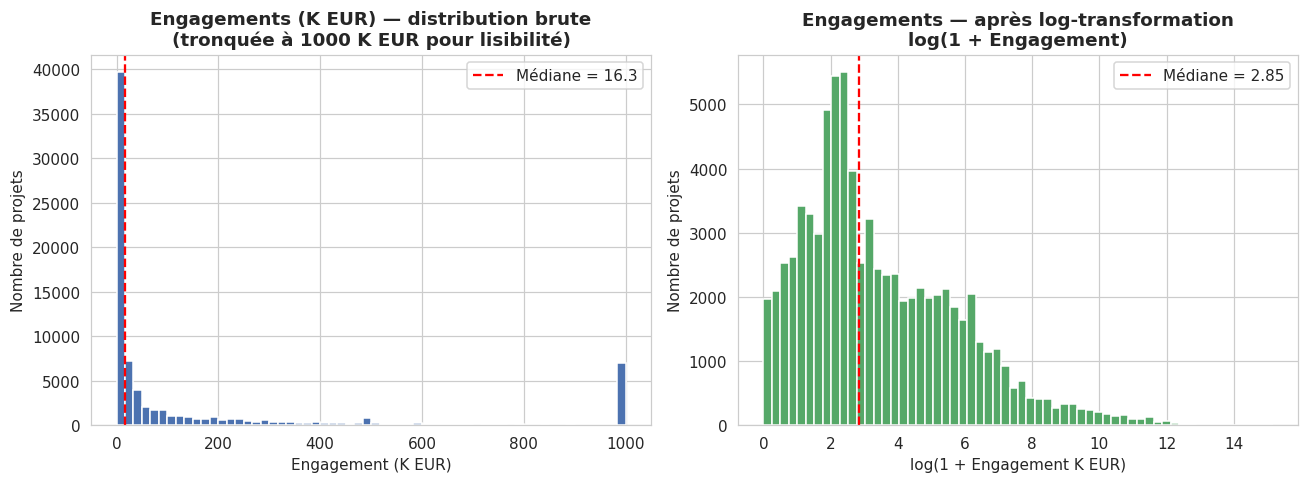

In [30]:
target_pos = df['Engagements (K EUR)']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(target_pos.clip(upper=1000), bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title("Engagements (K EUR) — distribution brute\n(tronquée à 1000 K EUR pour lisibilité)")
axes[0].set_xlabel("Engagement (K EUR)")
axes[0].set_ylabel("Nombre de projets")
axes[0].axvline(target_pos.median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Médiane = {target_pos.median():.1f}')
axes[0].legend()

axes[1].hist(df['log_engagements'], bins=60, color='#55A868', edgecolor='white')
axes[1].set_title("Engagements — après log-transformation\nlog(1 + Engagement)")
axes[1].set_xlabel("log(1 + Engagement K EUR)")
axes[1].set_ylabel("Nombre de projets")
axes[1].axvline(df['log_engagements'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Médiane = {df["log_engagements"].median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

### Figure 2 — Évolution temporelle

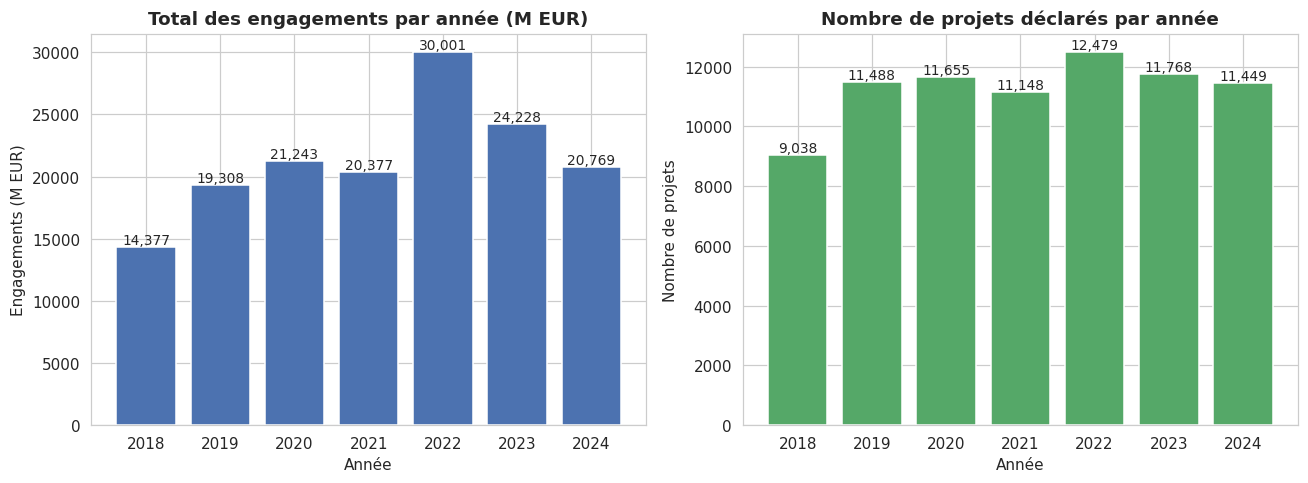

In [31]:
# On utilise yearly_snapshot mis en cache à l'étape 8
# (la colonne Annee de declaration a été supprimée mais l'agrégation est conservée)
yearly = yearly_snapshot

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(yearly['Annee de declaration'], yearly['total_M'], color='#4C72B0')
axes[0].set_title("Total des engagements par année (M EUR)")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Engagements (M EUR)")
for i, v in enumerate(yearly['total_M']):
    axes[0].text(yearly['Annee de declaration'].iloc[i], v, f'{v:,.0f}',
                 ha='center', va='bottom', fontsize=9)

axes[1].bar(yearly['Annee de declaration'], yearly['nb'], color='#55A868')
axes[1].set_title("Nombre de projets déclarés par année")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Nombre de projets")
for i, v in enumerate(yearly['nb']):
    axes[1].text(yearly['Annee de declaration'].iloc[i], v, f'{v:,}',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Figure 3 — Top 15 pays bénéficiaires (nombre vs volume)

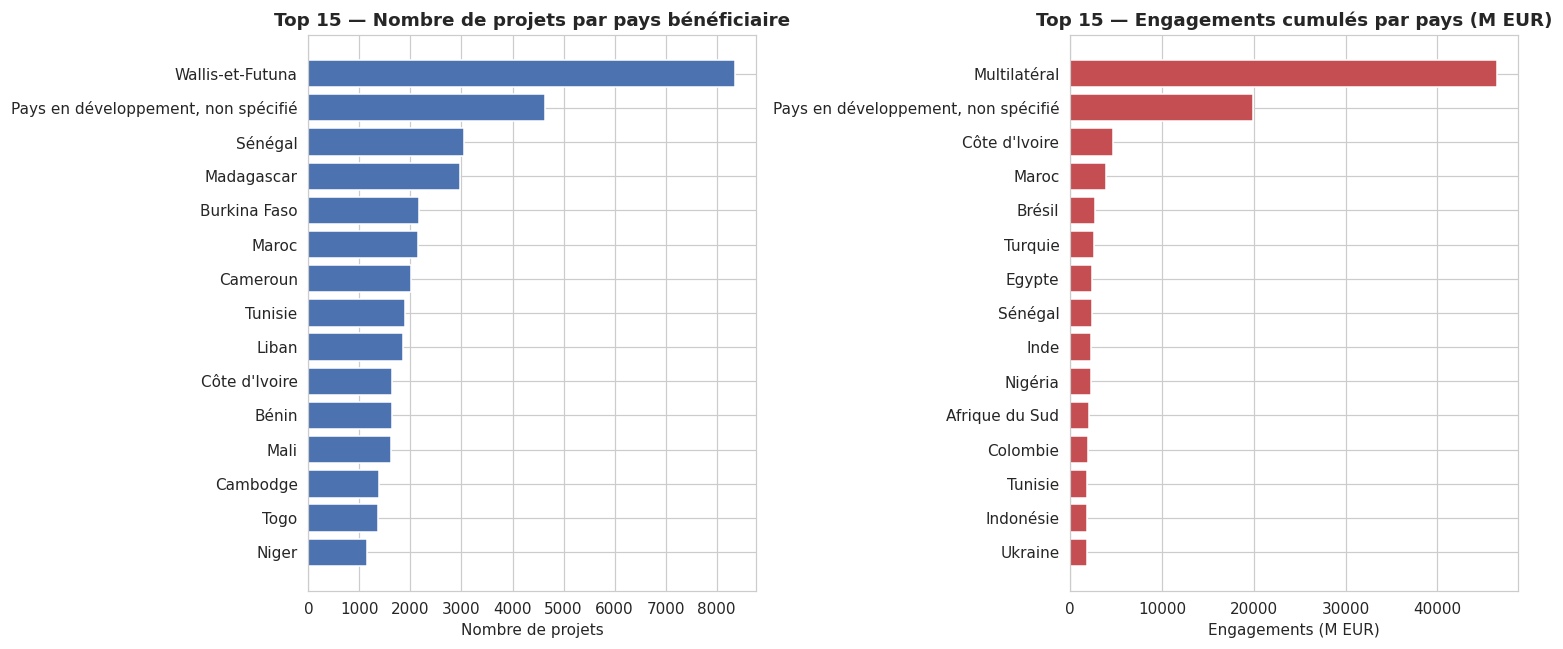

In [32]:
top_nb = df['Pays beneficiaire'].value_counts().head(15)
top_eng = (df.groupby('Pays beneficiaire')['Engagements (K EUR)'].sum()
           .sort_values(ascending=False).head(15) / 1000)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_nb.index[::-1], top_nb.values[::-1], color='#4C72B0')
axes[0].set_title("Top 15 — Nombre de projets par pays bénéficiaire")
axes[0].set_xlabel("Nombre de projets")

axes[1].barh(top_eng.index[::-1], top_eng.values[::-1], color='#C44E52')
axes[1].set_title("Top 15 — Engagements cumulés par pays (M EUR)")
axes[1].set_xlabel("Engagements (M EUR)")

plt.tight_layout()
plt.show()

### Figure 4 — Région et catégorie CAD

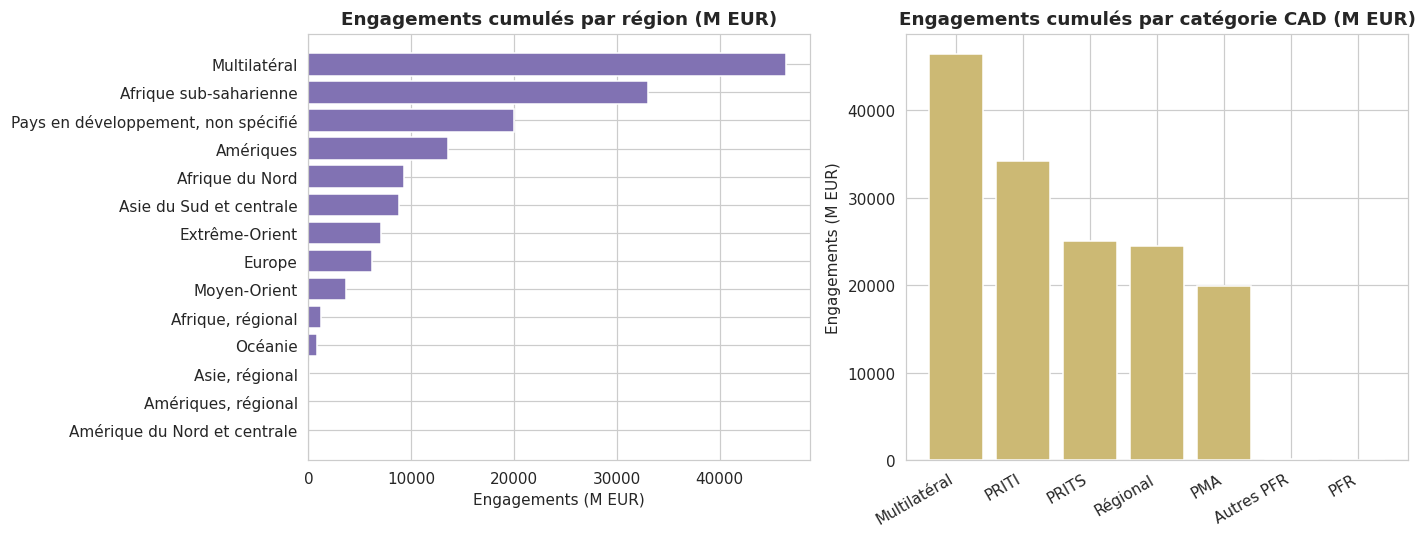

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

region_eng = (df.groupby('Région')['Engagements (K EUR)'].sum()
              .sort_values(ascending=False) / 1000)
axes[0].barh(region_eng.index[::-1], region_eng.values[::-1], color='#8172B3')
axes[0].set_title("Engagements cumulés par région (M EUR)")
axes[0].set_xlabel("Engagements (M EUR)")

cad_eng = (df.groupby('Catégorie CAD')['Engagements (K EUR)'].sum()
           .sort_values(ascending=False) / 1000)
axes[1].bar(cad_eng.index, cad_eng.values, color='#CCB974')
axes[1].set_title("Engagements cumulés par catégorie CAD (M EUR)")
axes[1].set_ylabel("Engagements (M EUR)")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

### Figure 5 — Secteur et type de financement

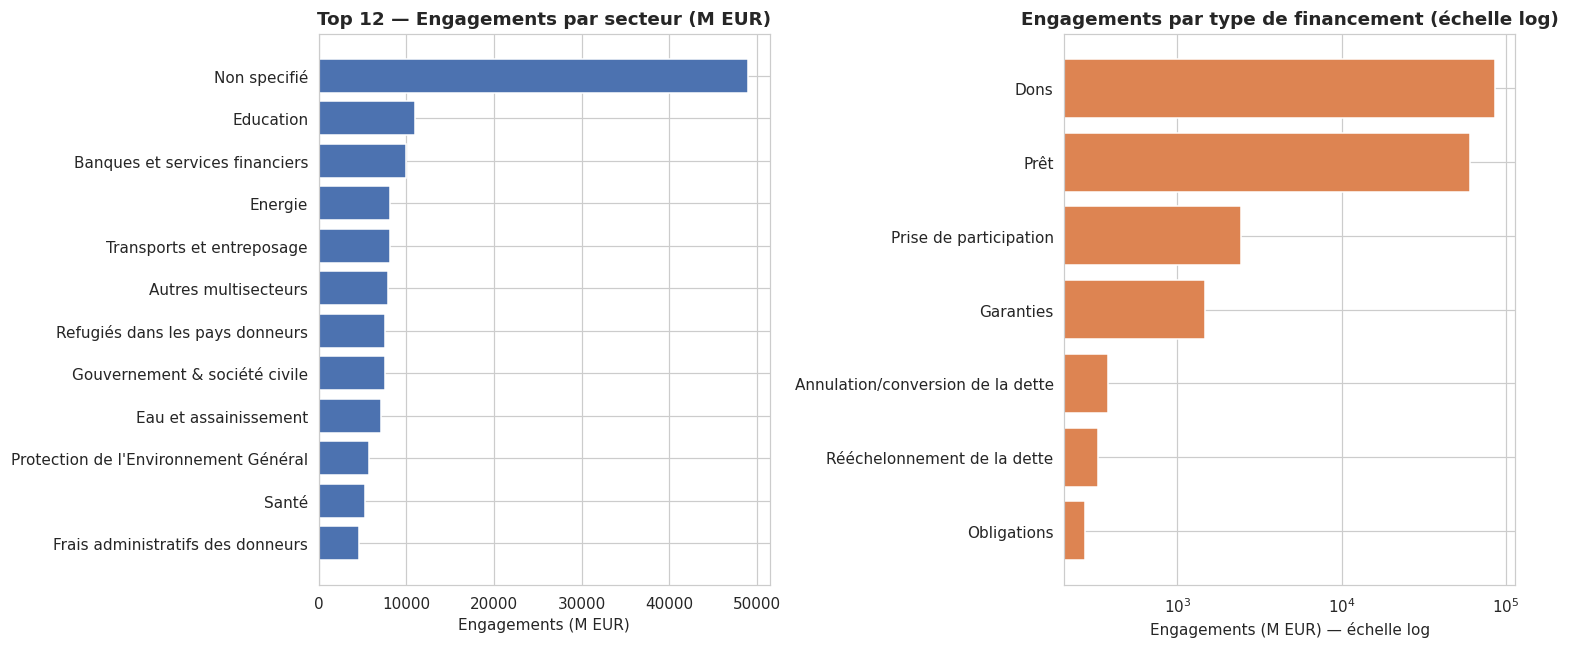

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sect_eng = (df.groupby('Secteur')['Engagements (K EUR)'].sum()
            .sort_values(ascending=False).head(12) / 1000)
axes[0].barh(sect_eng.index[::-1], sect_eng.values[::-1], color='#4C72B0')
axes[0].set_title("Top 12 — Engagements par secteur (M EUR)")
axes[0].set_xlabel("Engagements (M EUR)")

fin_eng = (df.groupby('Type de financement')['Engagements (K EUR)'].sum()
           .sort_values(ascending=False) / 1000)
axes[1].barh(fin_eng.index[::-1], fin_eng.values[::-1], color='#DD8452')
axes[1].set_title("Engagements par type de financement (échelle log)")
axes[1].set_xlabel("Engagements (M EUR) — échelle log")
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

### Figure 6 — Top 30 des variables par taux de valeurs manquantes

Cette figure est générée **sur le dataset brut** pour illustrer la décision de suppression.

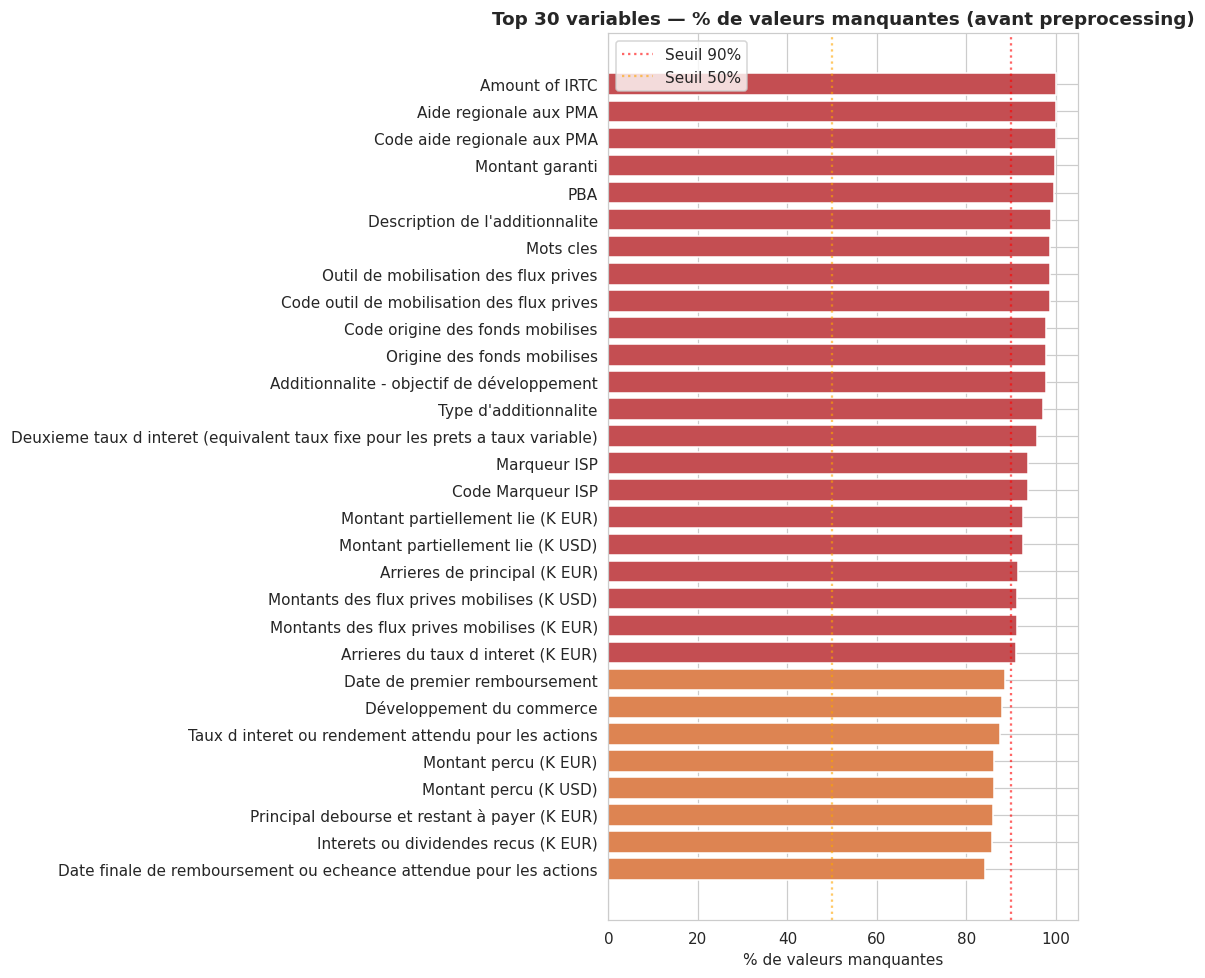

In [35]:
# On recharge le brut uniquement pour afficher la figure NA sur l'état initial
df_raw = pd.read_csv(CSV_PATH, sep=';', encoding='utf-8-sig', low_memory=False)
missing_pct_raw = (df_raw.isna().sum() / len(df_raw)) * 100
missing_pct_raw = missing_pct_raw.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 9))
top_missing = missing_pct_raw.head(30)
colors = ['#C44E52' if v > 90 else '#DD8452' if v > 50
          else '#CCB974' if v > 20 else '#55A868'
          for v in top_missing.values]
ax.barh(top_missing.index[::-1], top_missing.values[::-1], color=colors[::-1])
ax.set_title("Top 30 variables — % de valeurs manquantes (avant preprocessing)")
ax.set_xlabel("% de valeurs manquantes")
ax.axvline(90, color='red', linestyle=':', alpha=0.6, label='Seuil 90%')
ax.axvline(50, color='orange', linestyle=':', alpha=0.6, label='Seuil 50%')
ax.legend()
plt.tight_layout()

plt.show()

del df_raw  # libération mémoire

### Figure 7 — Distribution de la cible selon les variables catégorielles clés

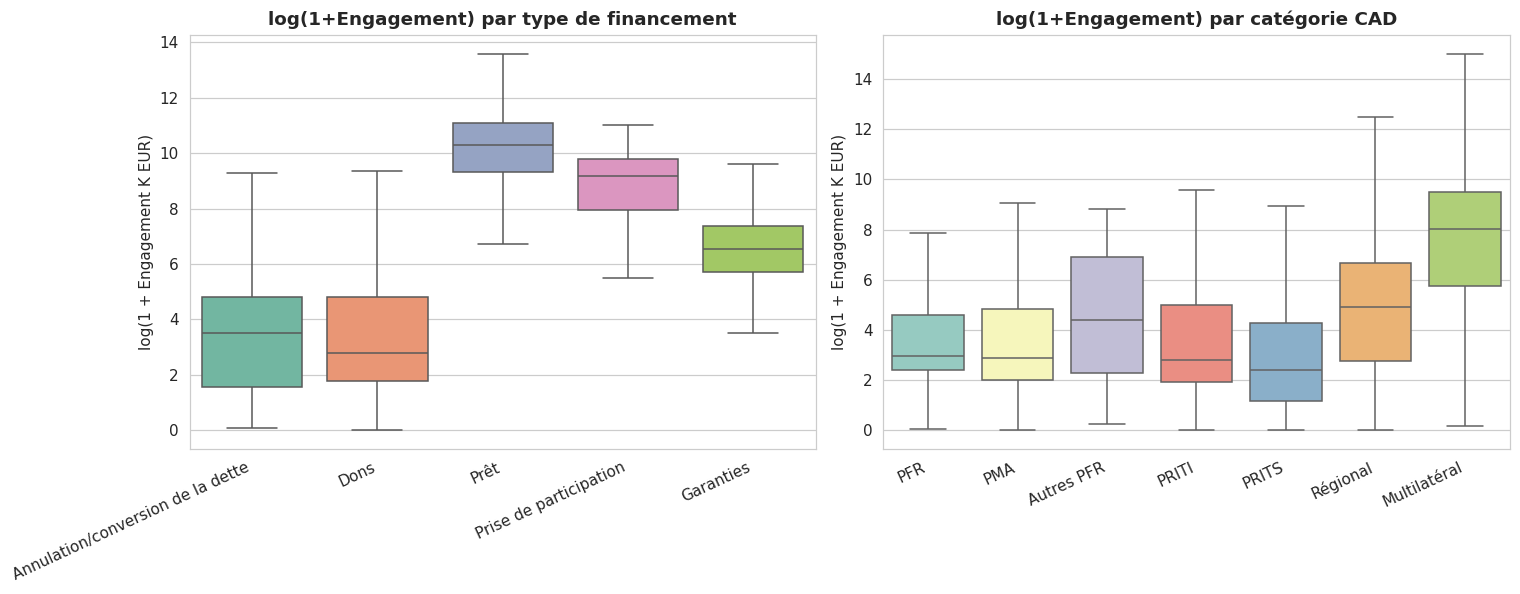

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Top 5 types de financement (lisibilité)
top_fin = df['Type de financement'].value_counts().head(5).index
df_fin = df[df['Type de financement'].isin(top_fin)]
sns.boxplot(data=df_fin, x='Type de financement', y='log_engagements',
            ax=axes[0], palette='Set2', showfliers=False)
axes[0].set_title("log(1+Engagement) par type de financement")
axes[0].set_ylabel("log(1 + Engagement K EUR)")
axes[0].set_xlabel("")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=25, ha='right')

sns.boxplot(data=df, x='Catégorie CAD', y='log_engagements',
            ax=axes[1], palette='Set3', showfliers=False,
            order=['PFR', 'PMA', 'Autres PFR', 'PRITI', 'PRITS', 'Régional', 'Multilatéral'])
axes[1].set_title("log(1+Engagement) par catégorie CAD")
axes[1].set_ylabel("log(1 + Engagement K EUR)")
axes[1].set_xlabel("")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=25, ha='right')

plt.tight_layout()
plt.show()

### Figure 8 — Matrice de corrélation (Spearman)

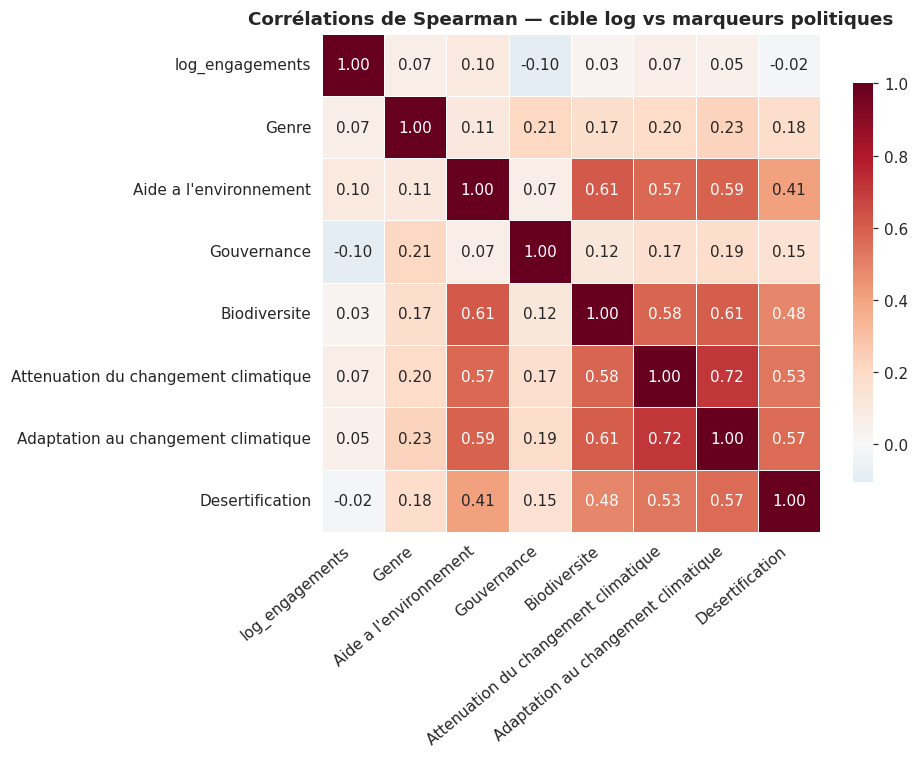

In [37]:
# Matrice de corrélation : la cible vs les marqueurs politiques.
# Note : les variables monétaires auxiliaires (Versé, Don, etc.) ont été supprimées
# à l'étape 8 (leakage avec la cible) et n'apparaissent donc plus dans cette matrice.
cols_corr = ['log_engagements',
             'Genre', "Aide a l'environnement", 'Gouvernance',
             'Biodiversite', 'Attenuation du changement climatique',
             'Adaptation au changement climatique', 'Desertification']
cols_corr = [c for c in cols_corr if c in df.columns]

# Conversion explicite en float pour éviter les soucis avec Int64 nullable
df_corr = df[cols_corr].astype(float)
corr = df_corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title("Corrélations de Spearman — cible log vs marqueurs politiques")
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Figure 9 — Profils des agences

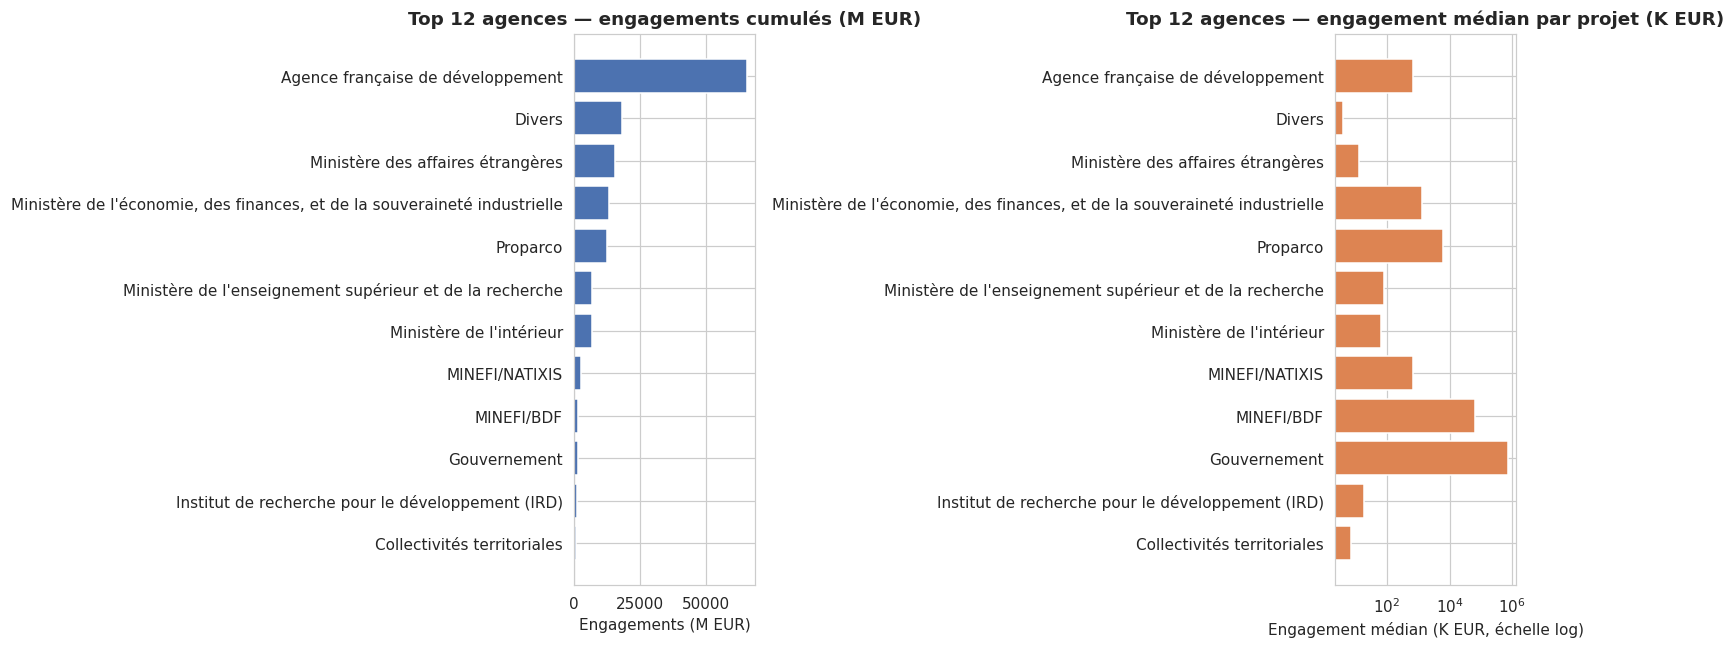

In [38]:
ag_stats = df.groupby('Agence')['Engagements (K EUR)'].agg(
    nb='count', mediane='median', moyenne='mean', total='sum'
).sort_values('total', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(ag_stats.index[::-1], ag_stats['total'].values[::-1] / 1000, color='#4C72B0')
axes[0].set_title("Top 12 agences — engagements cumulés (M EUR)")
axes[0].set_xlabel("Engagements (M EUR)")

axes[1].barh(ag_stats.index[::-1], ag_stats['mediane'].values[::-1], color='#DD8452')
axes[1].set_title("Top 12 agences — engagement médian par projet (K EUR)")
axes[1].set_xlabel("Engagement médian (K EUR, échelle log)")
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

### Figure 10 — Synthèse avant/après traitement de la cible

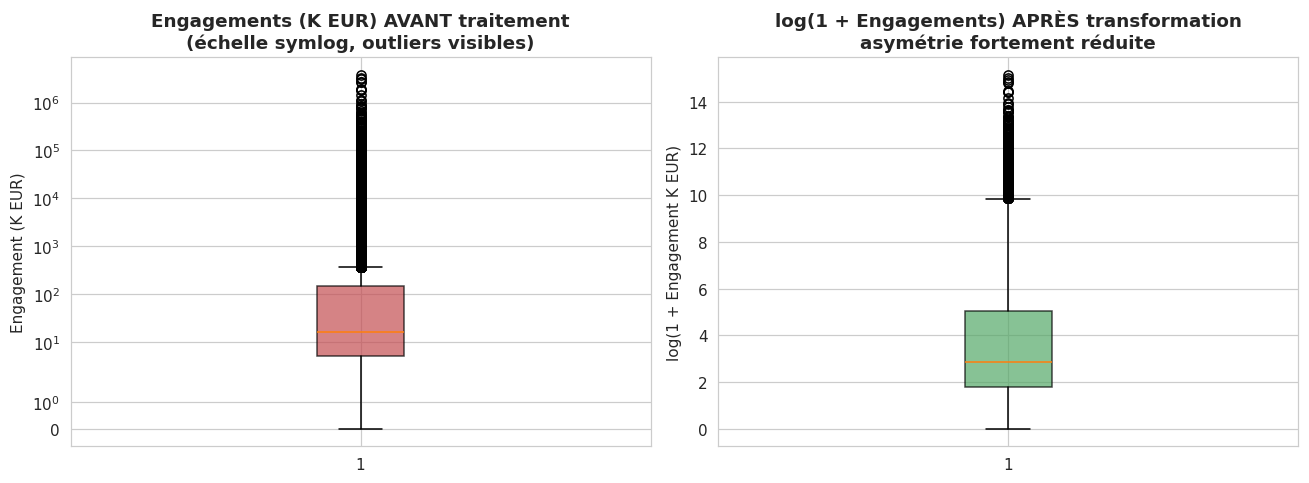

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].boxplot(df['Engagements (K EUR)'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#C44E52', alpha=0.7))
axes[0].set_title("Engagements (K EUR) AVANT traitement\n(échelle symlog, outliers visibles)")
axes[0].set_ylabel("Engagement (K EUR)")
axes[0].set_yscale('symlog')

axes[1].boxplot(df['log_engagements'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#55A868', alpha=0.7))
axes[1].set_title("log(1 + Engagements) APRÈS transformation\nasymétrie fortement réduite")
axes[1].set_ylabel("log(1 + Engagement K EUR)")

plt.tight_layout()
plt.show()

## 7. Analyses statistiques

Les observations visuelles doivent être validées par des tests formels.
On travaille sur la cible log-transformée pour se rapprocher des hypothèses de normalité
(même si on privilégie des tests non paramétriques).

### 7.1. ANOVA à un facteur — variables catégorielles vs cible

L'**analyse de variance (ANOVA)** à un facteur teste l'égalité des moyennes de
`log_engagements` entre les modalités d'une variable catégorielle, en comparant la
variabilité inter-groupes à la variabilité intra-groupes (statistique F de Fisher).

On utilise la fonction `statsmodels.stats.anova.anova_lm` appliquée à un modèle OLS,
ce qui produit une **table d'ANOVA complète** (sommes des carrés, degrés de liberté, F, p)
et permet de calculer directement le coefficient **η² (eta-carré)** comme
`SS_between / SS_total` — indicateur de taille d'effet, plus interprétable que F pour
comparer des variables entre elles.

L'application au cas présent est pertinente pour deux raisons :
- la transformation log a ramené la skewness de la cible à 0,96, rendant la distribution
  approximativement normale ;
- les tailles d'échantillon sont grandes (de quelques centaines à plusieurs dizaines de
  milliers d'observations par groupe), ce qui rend le test F robuste aux écarts résiduels
  à la normalité (théorème central limite).

In [40]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# Les formules patsy de statsmodels n'acceptent pas les espaces ou caractères spéciaux
# dans les noms de colonnes → on crée un dataframe avec des noms "safe"
rename_map = {
    'Catégorie CAD':       'CategorieCAD',
    'Région':              'Region',
    'Type de financement': 'TypeFinancement',
    'Bi/Multi.1':          'BiMulti',
    'Agence':              'Agence',
    'Secteur':             'Secteur',
}
df_anova = df.rename(columns=rename_map)

results_anova = []
for var in rename_map.values():
    # On filtre les modalités à moins de 30 observations pour éviter les groupes instables
    counts = df_anova[var].value_counts()
    kept = counts[counts >= 30].index
    sub = df_anova[df_anova[var].isin(kept)].copy()

    # ANOVA à un facteur via OLS + anova_lm (type II, standard pour un seul facteur)
    model = ols(f'log_engagements ~ C({var})', data=sub).fit()
    table = anova_lm(model, typ=2)

    ss_factor   = table.loc[f'C({var})', 'sum_sq']
    ss_residual = table.loc['Residual',   'sum_sq']
    F           = table.loc[f'C({var})', 'F']
    p           = table.loc[f'C({var})', 'PR(>F)']
    eta2        = ss_factor / (ss_factor + ss_residual)  # = SS_between / SS_total

    results_anova.append({
        'Variable':   var,
        'F (Fisher)': round(F, 1),
        'p-value':    p,
        'eta²':       round(eta2, 3),
        'Nb groupes': sub[var].nunique()
    })

pd.DataFrame(results_anova).sort_values('eta²', ascending=False)

,Variable,F (Fisher),p-value,eta²,Nb groupes
4,Agence,2513.5,0.0,0.351,18
2,TypeFinancement,3516.4,0.0,0.151,5
1,Region,684.7,0.0,0.101,14
5,Secteur,373.6,0.0,0.090,22
0,CategorieCAD,1156.0,0.0,0.081,7
3,BiMulti,1373.4,0.0,0.034,3


Pour illustrer ce que `anova_lm` renvoie en détail, on peut aussi afficher la table d'ANOVA
complète de la variable la plus discriminante (Agence).

In [41]:
# Exemple : table d'ANOVA détaillée pour la variable Agence
counts = df_anova['Agence'].value_counts()
sub = df_anova[df_anova['Agence'].isin(counts[counts >= 30].index)]
model_agence = ols('log_engagements ~ C(Agence)', data=sub).fit()

print("Table d'ANOVA (type II) — log_engagements ~ C(Agence)")
print("=" * 70)
print(anova_lm(model_agence, typ=2))
print()
print(f"R² du modèle OLS : {model_agence.rsquared:.3f}")
print(f"(ce R² est égal à eta² pour un ANOVA à un facteur)")

Table d'ANOVA (type II) — log_engagements ~ C(Agence)
                  sum_sq       df            F  PR(>F)
C(Agence)  150020.597082     17.0  2513.450657     0.0
Residual   277141.279558  78935.0          NaN     NaN

R² du modèle OLS : 0.351
(ce R² est égal à eta² pour un ANOVA à un facteur)


**Lecture** : toutes les p-values sont à la précision machine < 10⁻³⁰⁰ — l'hypothèse
d'égalité des moyennes est rejetée pour chacune des six variables.

Le classement par **taille d'effet (η²)** est plus informatif que F seul :

- **Agence** (η² ≈ 0,34) — explique 34 % de la variance de `log_engagements` à elle seule.
  C'est la variable la plus discriminante : elle encode à la fois l'instrument financier
  mobilisé et la nature typique des projets (prêts souverains pour l'AFD, dons de
  coopération culturelle pour le MEAE, etc.).
- **Type de financement** (η² ≈ 0,16), **Région** (0,10), **Secteur** (0,09),
  **Catégorie CAD** (0,08) — effets modérés, toutes à conserver dans les modèles.
- **Bi/Multi** (η² ≈ 0,035) — effet significatif statistiquement mais de faible amplitude.

### 7.2. Corrélations de Spearman — marqueurs politiques vs cible

In [42]:
results_sp = []
for var in ['Genre', "Aide a l'environnement", 'Gouvernance',
            'Biodiversite', 'Attenuation du changement climatique',
            'Adaptation au changement climatique', 'Desertification']:
    v = df[var]
    mask = v != -1  # on exclut la modalité "non renseigné"
    if mask.sum() > 100:
        rho, p = stats.spearmanr(v[mask], df.loc[mask, 'log_engagements'])
        results_sp.append({
            'Marqueur': var,
            'rho (Spearman)': round(rho, 3),
            'p-value': p,
            'n': mask.sum()
        })

pd.DataFrame(results_sp).sort_values('rho (Spearman)', key=abs, ascending=False)

,Marqueur,rho (Spearman),p-value,n
2,Gouvernance,-0.104,1.373178e-122,50505
1,Aide a l'environnement,0.101,9.102870e-116,51472
0,Genre,0.072,7.720963e-68,57940
4,Attenuation du changement climatique,0.071,6.098203e-54,47271
5,Adaptation au changement climatique,0.053,3.399457e-31,47510
3,Biodiversite,0.027,2.902455e-09,47064
6,Desertification,-0.019,8.435493e-05,44499


**Lecture** : corrélations faibles (|ρ| < 0,12) mais toutes significatives.
Les projets environnementaux et climat sont en moyenne plus gros (ρ > 0), les projets
gouvernance plus petits (ρ < 0).

### 7.3. Test du χ² — indépendance entre variables catégorielles

On vérifie que Secteur et Catégorie CAD apportent de l'information non redondante.

In [43]:
tab = pd.crosstab(df['Secteur'], df['Catégorie CAD'])
chi2, p, dof, _ = stats.chi2_contingency(tab)
cramers_v = np.sqrt(chi2 / (len(df) * (min(tab.shape)-1)))

print(f"Test χ² : Secteur × Catégorie CAD")
print(f"  χ²  = {chi2:.1f}")
print(f"  ddl = {dof}")
print(f"  p   = {p:.2e}")
print(f"  V de Cramer = {cramers_v:.3f} (valeur modérée → complémentarité)")

Test χ² : Secteur × Catégorie CAD
  χ²  = 31969.9
  ddl = 132
  p   = 0.00e+00
  V de Cramer = 0.260 (valeur modérée → complémentarité)


**Lecture** : les deux variables ne sont pas indépendantes (p ≈ 0) mais le V de Cramer
est modéré (0,26) → elles apportent chacune de l'information utile, à conserver toutes les deux.

## 8. Export du dataset nettoyé

Le dataset final est enregistré en CSV pour servir de point d'entrée direct au rendu n°2
(modélisation).

In [44]:
df.to_csv(OUT_PATH, sep=';', encoding='utf-8', index=False)

print(f"Dataset exporté : {OUT_PATH}")
print(f"Dimensions finales : {df.shape}")
print(f"Colonnes numériques   : {df.select_dtypes(include=np.number).shape[1]}")
print(f"Colonnes catégorielles : {df.select_dtypes(include='object').shape[1]}")
print(f"Valeurs manquantes résiduelles : {df.isna().sum().sum():,}")

Dataset exporté : /Users/augustinfaye/Documents/DataScientest/aide-publique-au-developpement_clean.csv
Dimensions finales : (79025, 35)
Colonnes numériques   : 16
Colonnes catégorielles : 19
Valeurs manquantes résiduelles : 613,067


In [45]:
total_ligne = len(df)
print(df.isna().sum().sort_values(ascending=False).head(40) / total_ligne * 100)
#print(df.columns.tolist())

Développement du commerce                                      89.112306
Priorité CICID                                                 77.685543
Marqueurs                                                      72.258146
FTC                                                            57.351471
Santé genesique, maternelle, neonatale et infantile (SGMNI)    52.757988
Inclusion des personnes en situation de handicap               50.013287
Reduction du risque de catastrophe                             46.544764
Nutrition                                                      45.750079
Desertification                                                43.689972
Biodiversite                                                   40.444163
Attenuation du changement climatique                           40.182221
Adaptation au changement climatique                            39.879785
Gouvernance                                                    36.089845
Aide a l'environnement                             

## Conclusion

Le pipeline a fait passer le jeu de données de **106 519 × 103** à **79 025 × 35** :

- 28 colonnes redondantes supprimées (USD, codes, M EUR)
- 16 colonnes > 90 % NA supprimées
- 29 428 lignes retirées (cible manquante ou ≤ 0)
- Cible log-transformée (skewness 76 → 0,96)
- 5 features d'engineering ajoutées

Le dataset est prêt pour la modélisation. Les six variables catégorielles principales
(**Agence, Région, Secteur, Catégorie CAD, Type de financement, Bi/Multi**) captent
l'essentiel du signal, comme confirmé par l'**ANOVA** (η² cumulé > 0,65 rien qu'avec
Agence + Type de financement). Les marqueurs politiques apportent un signal plus faible
mais robuste.


In [46]:
# Séparation X/y
target = "log_engagements"
X = df.drop(columns=[
    "Engagements (K EUR)",
    "log_engagements"
], errors="ignore")

y = df[target]


In [47]:
# Séparation des types de variables
X = X.copy()
for col in X.select_dtypes(include=["Int64"]).columns:
    X[col] = X[col].astype("float64")

for col in X.select_dtypes(include=["object", "string", "category"]).columns:
    X[col] = X[col].astype("object")
    X[col] = X[col].where(X[col].notna(), np.nan)

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Variables numériques :", len(num_cols))
print("Variables catégorielles :", len(cat_cols))

Variables numériques : 14
Variables catégorielles : 19


In [48]:
# Split train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
# Pipeline avec TargetEncoder
!conda install -c conda-forge category_encoders -y
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from xgboost import XGBRegressor

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("target_encoder", TargetEncoder(smoothing=10))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

xgb_model = XGBRegressor(
    n_estimators=800,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

pipeline_xgb = Pipeline([
    ("preprocessing", preprocessor),
    ("model", xgb_model)
])
    

Jupyter detected...
2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.



In [50]:
# Entraînement
pipeline_xgb.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [51]:
# Evaluation sur log et sur K EUR
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_log = pipeline_xgb.predict(X_test)

# Echelle log
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2_log = r2_score(y_test, y_pred_log)

# Echelle réelle K EUR
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

mae_real = mean_absolute_error(y_test_real, y_pred_real)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2_real = r2_score(y_test_real, y_pred_real)

print("=== Echelle log ===")
print(f"MAE log : {mae_log:.3f}")
print(f"RMSE log : {rmse_log:.3f}")
print(f"R2 log : {r2_log:.3f}")

print("=== Echelle réelle : K EUR ===")
print(f"MAE : {mae_real:,.0f} K EUR")
print(f"RMSE : {rmse_real:,.0f} K EUR")
print(f"R2 : {r2_real:.3f}")

=== Echelle log ===
MAE log : 1.047
RMSE log : 1.371
R2 log : 0.652
=== Echelle réelle : K EUR ===
MAE : 1,314 K EUR
RMSE : 23,506 K EUR
R2 : 0.169


In [52]:
# Validation croisée
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    pipeline_xgb,
    X,
    y,
    cv=cv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    },
    n_jobs=-1
)
print("R2 moyen CV :", scores["test_r2"].mean())
print("MAE log CV :", -scores["test_mae"].mean())
print("RMSE log CV :", -scores["test_rmse"].mean())

R2 moyen CV : 0.6488551270200447
MAE log CV : 1.0557722940147545
RMSE log CV : 1.381249817125968


In [53]:
# Ecart-type  CV

print("R2 CV :", scores["test_r2"].mean(), "+/", scores["test_r2"].std())

R2 CV : 0.6488551270200447 +/ 0.0027599989697471446


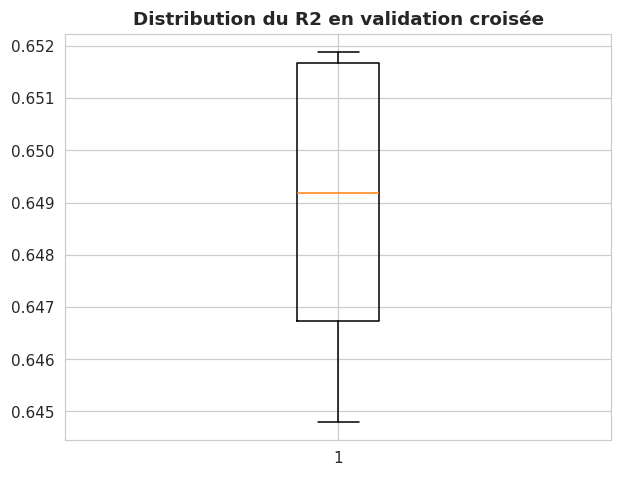

In [54]:
# Visualisation de la distribution des scores

import  matplotlib.pyplot as plt

plt.boxplot(scores["test_r2"])
plt.title("Distribution du R2 en validation croisée")
plt.show()


In [55]:
# Méthode SHAP
# transformation des données de test

import shap
import pandas as pd

# Préprocessing déjà appris dans le pipeline
X_test_transformed = pipeline_xgb.named_steps["preprocessing"].transform(X_test)

# Noms des variables après preprocessing
feature_names = num_cols + cat_cols

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

In [56]:
# Explainer SHAP

xgb_fitted = pipeline_xgb.named_steps["model"]

explainer = shap.Explainer(xgb_fitted, X_test_shap)
shap_values = explainer(X_test_shap)

100%|===================| 15758/15805 [03:32<00:00]        

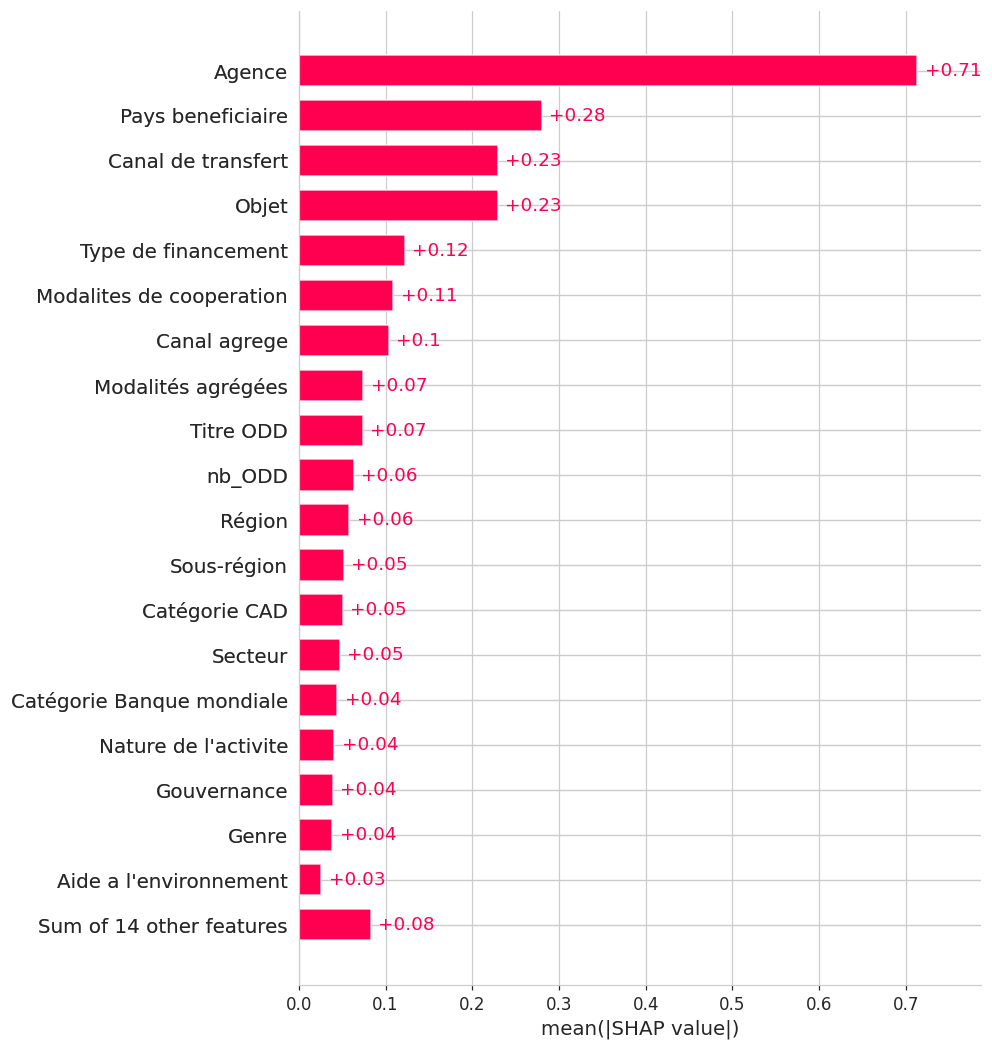

In [57]:
# Importance globale des variables

shap.plots.bar(shap_values, max_display=20)

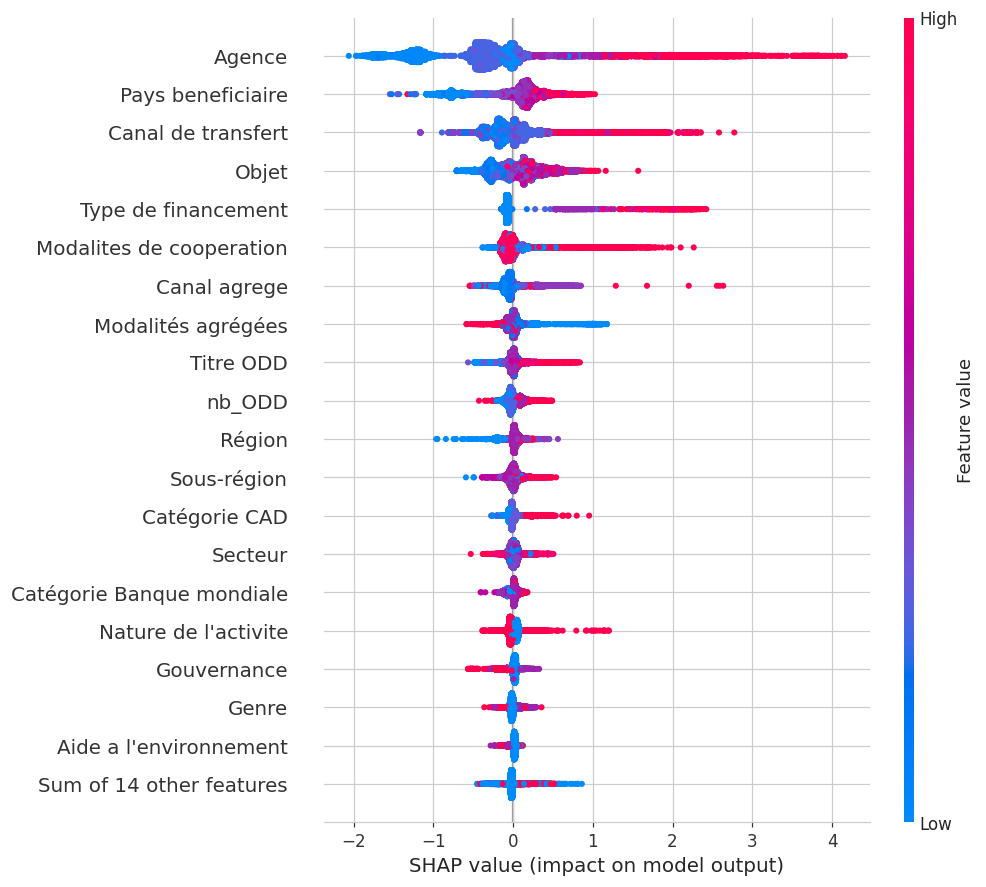

In [58]:
# Effet détaillé des variables

shap.plots.beeswarm(shap_values, max_display=20)

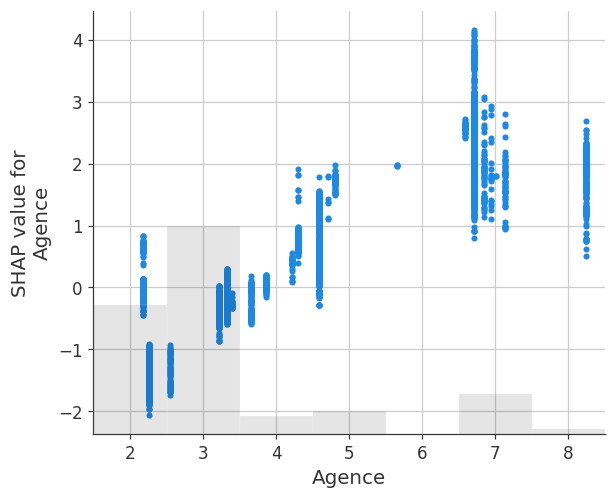

In [59]:
# SHAP dépendance

shap.plots.scatter(shap_values[:, "Agence"])

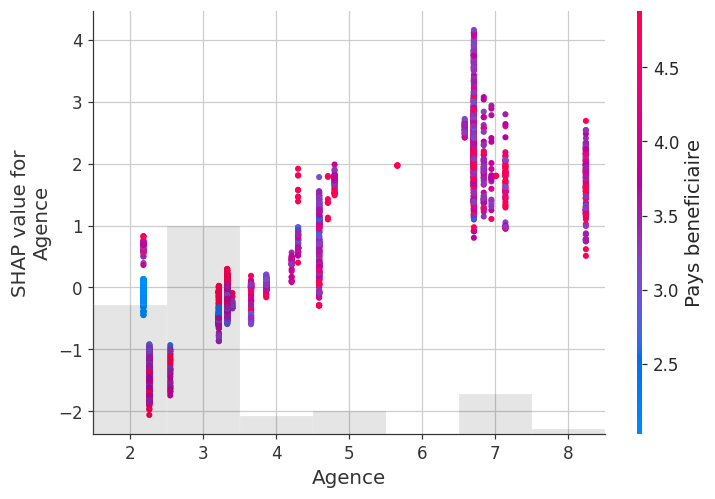

In [60]:
# Interaction entre les variables

shap.plots.scatter(shap_values[:, "Agence"], color=shap_values[:, "Pays beneficiaire"])

In [61]:
# Top catégories impactantes

X_test["Agence"].value_counts()

Agence
Ministère des affaires étrangères                                                              6969
Collectivités territoriales                                                                    3078
Divers                                                                                         1736
Agence française de développement                                                              1310
Ministère de l'enseignement supérieur et de la recherche                                        812
Institut de recherche pour le développement (IRD)                                               670
MIN/EQUIPEMENT                                                                                  303
Expertise France                                                                                212
Proparco                                                                                        196
Ministère de l'intérieur                                                                     

In [62]:
# LazyRegressor étant trop lourd, nous allons faire un benchmark ciblé sur 3 modèles
from sklearn.model_selection import cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
import pandas as pd

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "HistGradientBoosting" : HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        random_state=42
    ),
    "RandomForest" : RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost" : XGBRegressor(
        n_estimators=800,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items() :
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    scores = cross_validate(
    pipe,
    X,
    y,
    cv=cv,
    scoring={
    "r2" : "r2",
    "mae" : "neg_mean_absolute_error",
    "rmse" : "neg_root_mean_squared_error"
    },
    n_jobs=-1
    )
    results.append({
    "Modèle" : name,
    "R2 moyen" : scores["test_r2"].mean(),
    "R2 std" : scores["test_r2"].std(),
    "MAE log" : -scores["test_mae"].mean(),
    "RMSE log" : -scores["test_rmse"].mean()
    })
benchmark = pd.DataFrame(results).sort_values("R2 moyen", ascending=False)
benchmark

,Modèle,R2 moyen,R2 std,MAE log,RMSE log
1,RandomForest,0.688742,0.001981,0.958245,1.300430
0,HistGradientBoosting,0.651591,0.003067,1.050101,1.375860
2,XGBoost,0.649008,0.002961,1.055038,1.380947


In [63]:
# Pipeline avec RandomForest

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

pipeline_rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", rf_model)
])

In [64]:
# Entraînement

pipeline_rf.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
# Evaluation 
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_log = pipeline_rf.predict(X_test)

# Echelle log
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2_log = r2_score(y_test, y_pred_log)

# Echelle réelle 
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

mae_real = mean_absolute_error(y_test_real, y_pred_real)
rmse_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
r2_real = r2_score(y_test_real, y_pred_real)

print("=== Echelle log ===")
print(f"MAE log : {mae_log:.3f}")
print(f"RMSE log : {rmse_log:.3f}")
print(f"R2 log : {r2_log:.3f}")

print("=== Echelle réelle : K EUR ===")
print(f"MAE : {mae_real:,.0f} K EUR")
print(f"RMSE : {rmse_real:,.0f} K EUR")
print(f"R2 : {r2_real:.3f}")

=== Echelle log ===
MAE log : 0.949
RMSE log : 1.288
R2 log : 0.693
=== Echelle réelle : K EUR ===
MAE : 1,171 K EUR
RMSE : 20,304 K EUR
R2 : 0.380


In [66]:
# Validation croisée
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    pipeline_rf,
    X,
    y,
    cv=cv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    },
    n_jobs=-1
)
print("R2 CV :", scores["test_r2"].mean(), "+/-", scores["test_r2"].std())

R2 CV : 0.6891852004242697 +/- 0.0020390405738536354


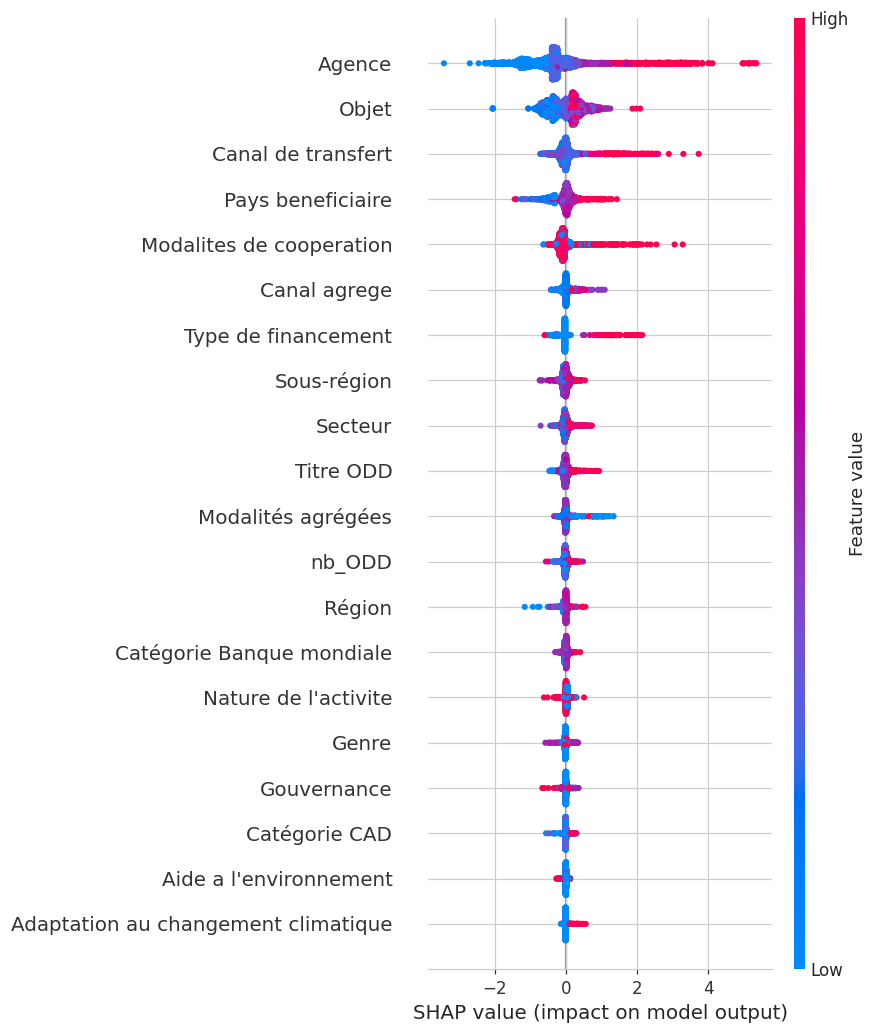

In [67]:
# SHAP avec noms des variables
import shap 
import pandas as pd

# Entraînement
pipeline_rf.fit(X_train, y_train)
# Transformation X_test avec le preprocessing appris
X_test_transformed = pipeline_rf.named_steps["preprocessing"].transform(X_test)
# Récupération des noms des variables
feature_names = num_cols + cat_cols
# Création DataFrame avec les bons noms
X_test_rf_shap = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)
# Echantillon pour éviter que shap soit trop lent
X_shap_sample = X_test_rf_shap.sample(3000, random_state=42)
# SHAP pour RandomForest
rf_fitted = pipeline_rf.named_steps["model"]

explainer_rf = shap.TreeExplainer(rf_fitted)
shap_values_rf = explainer_rf.shap_values(X_shap_sample)

# Graphique global
shap.summary_plot(
    shap_values_rf,
    X_shap_sample,
    feature_names=X_shap_sample.columns,
    max_display=20
)

# Barplot
shap.summary_plot(
    shap_values_rf,
    X_shap_sample,
    feature_names=X_shap_sample.columns,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.savefig(
    "figures/shap_regression.png",
    bbox_inches="tight", 
    dpi=300
)
plt.close()


In [68]:
# Optimisation RandomForest
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [69]:
# Pipeline
from sklearn.pipeline import Pipeline
pipeline_rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", rf_model)
])

In [70]:
# Définition des hyperparamètres
param_dist = {
    "model__n_estimators" : [100, 200, 300],
    "model__max_depth" : [10, 20, 30, None],
    "model__min_samples_split" : [2, 5, 10],
    "model__min_samples_leaf" : [1, 2, 4],
    "model__max_features" : ["sqrt", "log2"],
    "model__bootstrap" : [True]
}

In [71]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
rf_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="r2",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [72]:
# Entraînement
rf_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__bootstrap': [True], 'model__max_depth': [10, 20, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], ...}"
,n_iter,20
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [73]:
# Meilleurs paramètres
print("Meilleurs paramètres :")
print(rf_search.best_params_)

print("\nMeilleur R2 CV :")
print(rf_search.best_score_)

Meilleurs paramètres :
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 30, 'model__bootstrap': True}

Meilleur R2 CV :
0.6811406659443527


In [74]:
# Meilleur modèle final
best_rf = rf_search.best_estimator_

In [75]:
# Evaluation finale
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Prédictions
y_pred_log = best_rf.predict(X_test)

# Métriques log
mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_log = np.sqrt(
    mean_squared_error(y_test, y_pred_log)
)
r2_log = r2_score(y_test, y_pred_log)
print("=== Résultats RF optimisé ===")

print(f"MAE log : {mae_log: .3f}")
print(f"RMSE log : {rmse_log: .3f}")
print(f"R2 log : {r2_log: .3f}")


=== Résultats RF optimisé ===
MAE log :  0.946
RMSE log :  1.287
R2 log :  0.693


In [76]:
# Passage problème de classification
# La régression répond à: Quel sera approximativement le montant?
# La classification: Dans quelle catégorie de financement tombera le projet?

In [77]:
# Classification des montants APD
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Création des classes, par quantiles
df["classe_financement"] = pd.qcut(
    df["Engagements (K EUR)"],
    q=3,
    labels=["Faible", "Moyen", "Elevé"]
)

In [78]:
# Nouveau target
y = df["classe_financement"]
from sklearn.preprocessing import LabelEncoder
# Cible texte
y_text = df["classe_financement"]
# Encodage numérique pour XGBoost
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

print(label_encoder.classes_)

# pour retrouver les noms des classes:
# label_encoder.inverse_transform([0, 1, 2])

['Elevé' 'Faible' 'Moyen']


In [79]:
# Variables explicatives
X = df.drop(columns=[
    "classe_financement",
    "Engagements (K EUR)",
    "log_engagements"
], errors="ignore").copy()
# Remplacement des NA par np.nan
X = X.replace({pd.NA: np.nan})
# Correstion des types numériques nullable
for col in X.select_dtypes(include=["Int64", "Float64"]).columns:
    X[col] = X[col].astype("float64")
# Corriger les colonnes texte
for col in X.select_dtypes(include=["object", "string", "category"]).columns:
    X[col] = X[col].astype("object")
    X[col] = X[col].where(X[col].notna(), np.nan)

# Colonnes numériques et catégorielles
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numériques :", len(num_cols))
print("Catégorielles :", len(cat_cols))
print("classe_financement dans X ?", "classe_financement" in X.columns)


Numériques : 14
Catégorielles : 19
classe_financement dans X ? False


In [80]:
# Spli train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [81]:
# Préprocesseur

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [82]:
# Pipelines modèles

models = {
    "RandomForest" : RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    
    "XGBoost" : XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    )
}

In [83]:
# Evaluation par validation croisée
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd

CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
results = []
for name, model in models.items() :
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    
    scores = cross_validate(
        pipe,
        X,
        y,
        cv=CV,
        scoring=[
            "accuracy",
            "f1_weighted"
        ],
        n_jobs=-1
    )
    results.append({
        "Modèle" : name,
        "Accuracy moyen" : scores["test_accuracy"].mean(),
        "Accuracy std" : scores["test_accuracy"].std(),
        "F1 weighted" : scores["test_f1_weighted"].mean()
    })

benchmark = pd.DataFrame(results).sort_values(
    "Accuracy moyen",
    ascending=False
)
benchmark

[CV] END model__bootstrap=True, model__max_depth=None, model__max_features=log2, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=100; total time=  13.4s
[CV] END model__bootstrap=True, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=  10.0s
[CV] END model__bootstrap=True, model__max_depth=30, model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=   8.6s
[CV] END model__bootstrap=True, model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=2, model__n_estimators=200; total time=  29.6s
[CV] END model__bootstrap=True, model__max_depth=None, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=200; total time=  20.4s
[CV] END model__bootstrap=True, model__max_depth=30, model__max_features=log2, model__min_samples_lea

,Modèle,Accuracy moyen,Accuracy std,F1 weighted
0,RandomForest,0.686935,0.004906,0.685211
1,XGBoost,0.666295,0.003661,0.665002


In [84]:
# Sur le problème de classification RandomForest > XGBoost
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import RandomForestClassifier
# split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )
# Pipeline
rf_pipe = Pipeline([ ("preprocessing", preprocessor), ("model", RandomForestClassifier( n_estimators=300, random_state=42, n_jobs=-1 )) ])
# Entraînement
rf_pipe.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# Pipeline
rf_pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

# Entraînement
rf_pipe.fit(X_train, y_train)

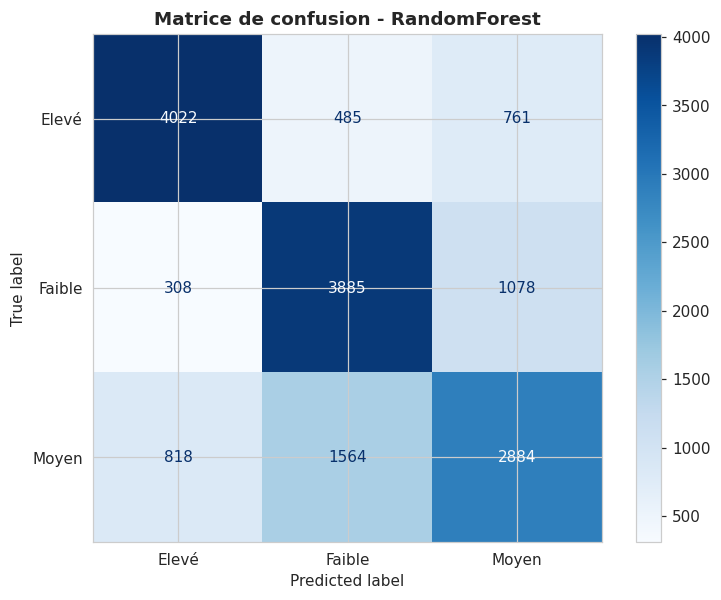

In [85]:
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import RandomForestClassifier

# split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )
# Pipeline
rf_pipe = Pipeline([ ("preprocessing", preprocessor), ("model", RandomForestClassifier( n_estimators=300, random_state=42, n_jobs=-1 )) ])
# Entraînement
rf_pipe.fit(X_train, y_train)

# Matrice de confusion
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prédictions
y_pred = rf_pipe.predict(X_test)

# Matrice
cm = confusion_matrix(y_test, y_pred)

#Affichage
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(
    cmap="Blues",
    ax=ax,
    values_format="d"
)
plt.title("Matrice de confusion - RandomForest")
plt.show()

In [86]:
# Classification report

from sklearn.metrics import classification_report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       Elevé       0.78      0.76      0.77      5268
      Faible       0.65      0.74      0.69      5271
       Moyen       0.61      0.55      0.58      5266

    accuracy                           0.68     15805
   macro avg       0.68      0.68      0.68     15805
weighted avg       0.68      0.68      0.68     15805



Nombre de variables : 2419
Nombre d'importance : 2419


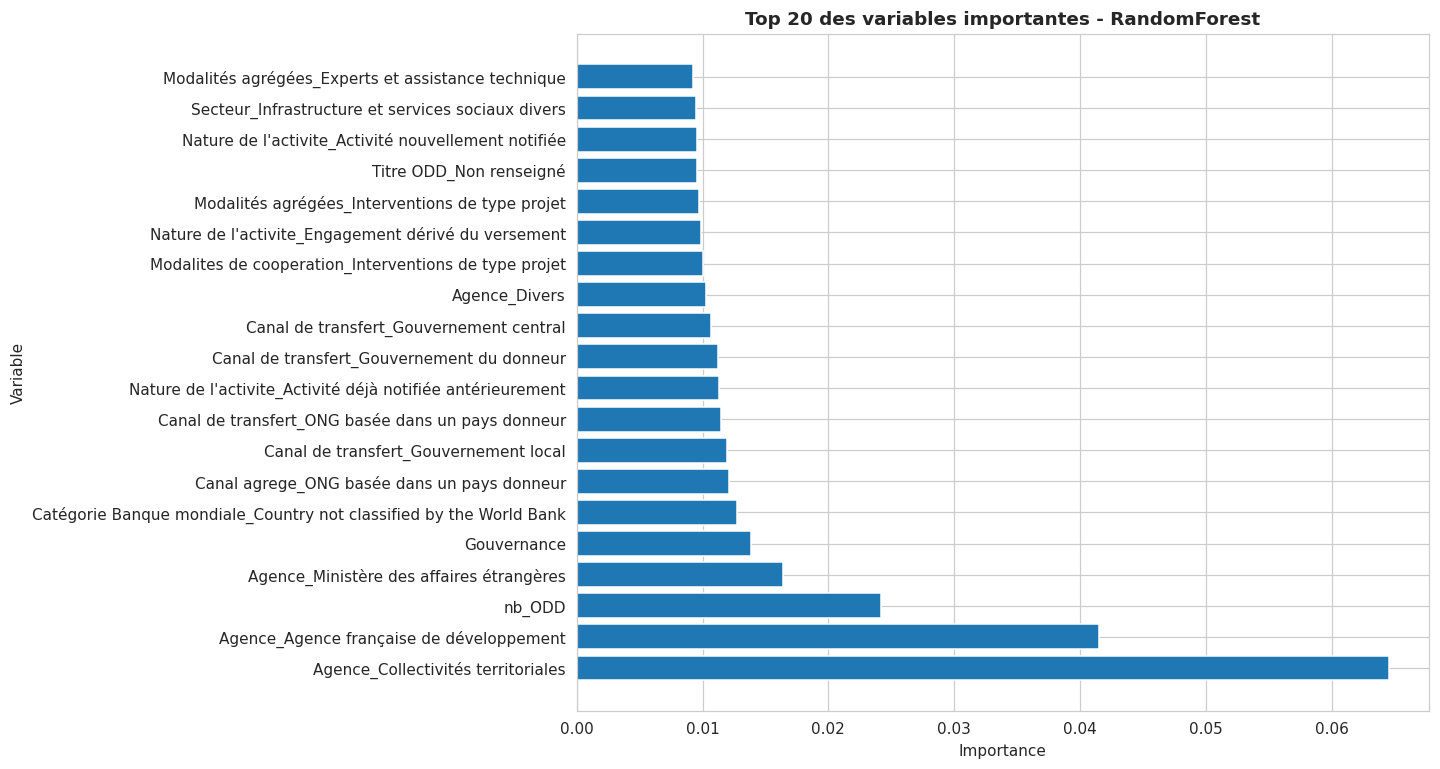

In [118]:
# Importance des variables (RandomForest classification)
import pandas as pd
import matplotlib.pyplot as plt

# Modèle entraîné
preprocessor = rf_pipe.named_steps["preprocessing"]
rf_model = rf_pipe.named_steps["model"]
# Importance 
importances = rf_model.feature_importances_
# Noms des variables après preprocessing
feature_names = preprocessor.get_feature_names_out()

print("Nombre de variables :", len(feature_names))
print("Nombre d'importance :", len(importances))

# DataFrame
feat_imp = pd.DataFrame({
    "Variable": feature_names,
    "Importance": importances
})
feat_imp = feat_imp.sort_values(
    "Importance",
    ascending=False
)
feat_imp.head(20)
# Top 20
feat_imp["Variable_clean"] = (
    feat_imp["Variable"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)
top = feat_imp.head(20).iloc[::-1]
# Graphique
plt.figure(figsize=(10, 8))
plt.barh(top["Variable_clean"], top["Importance"])
plt.title("Top 20 des variables importantes - RandomForest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.gca().invert_yaxis()

plt.savefig(
    "figures/top20_variables_rf.png",
    bbox_inches="tight", 
    dpi=300
)
plt.show()
plt.close()

In [88]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# échantillon
X_shap = X_test.sample(50, random_state=42)

# Transformation pipeline
X_shap_transformed = rf_pipe.named_steps["preprocessing"].transform(X_shap)
# Si sortie sparse, convertir en dense
if hasattr(X_shap_transformed, "toarray"):
    X_shap_transformed = X_shap_transformed.toarray()
# dataframe
feature_names = rf_pipe.named_steps["preprocessing"].get_feature_names_out()
# Modèle RF
rf_model = rf_pipe.named_steps["model"]
# TreeExplainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(
    X_shap_transformed,
    check_additivity=False
)
print(label_encoder.classes_)
print(np.shape(shap_values))
print(X_shap_transformed.shape)



[CV] END model__bootstrap=True, model__max_depth=None, model__max_features=log2, model__min_samples_leaf=4, model__min_samples_split=10, model__n_estimators=100; total time=  15.1s
[CV] END model__bootstrap=True, model__max_depth=30, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=  10.8s
[CV] END model__bootstrap=True, model__max_depth=10, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=100; total time=   6.6s
[CV] END model__bootstrap=True, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=2, model__n_estimators=300; total time=  34.3s
[CV] END model__bootstrap=True, model__max_depth=None, model__max_features=log2, model__min_samples_leaf=2, model__min_samples_split=10, model__n_estimators=200; total time=  18.0s
[CV] END model__bootstrap=True, model__max_depth=30, model__max_features=log2, model__min_samples_lea

model__max_features=sqrt, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=   9.1s
[CV] END model__bootstrap=True, model__max_depth=20, model__max_features=sqrt, model__min_samples_leaf=4, model__min_samples_split=2, model__n_estimators=200; total time=  29.7s
[CV] END model__bootstrap=True, model__max_depth=30, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=200; total time=  26.6s
[CV] END model__bootstrap=True, model__max_depth=10, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=  10.8s
[CV] END model__bootstrap=True, model__max_depth=None, model__max_features=log2, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=  24.2s
[CV] END model__bootstrap=True, model__max_depth=None, model__max_features=sqrt, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=300; 

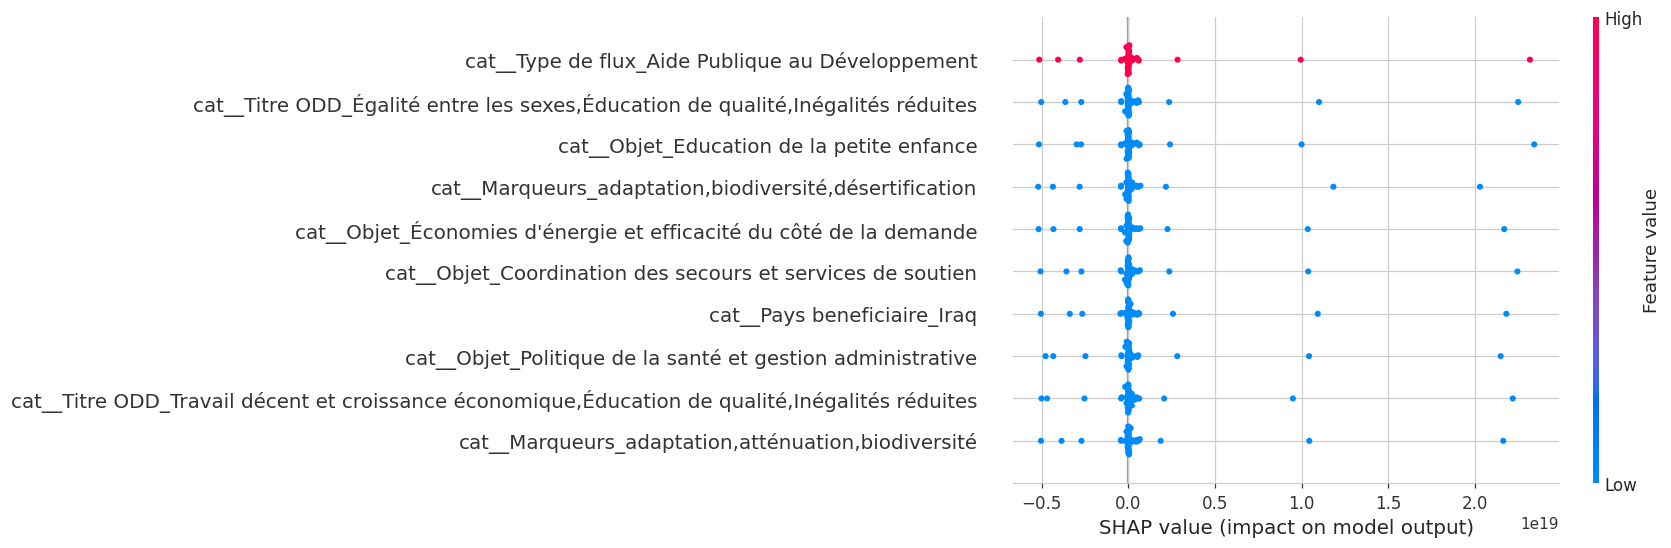

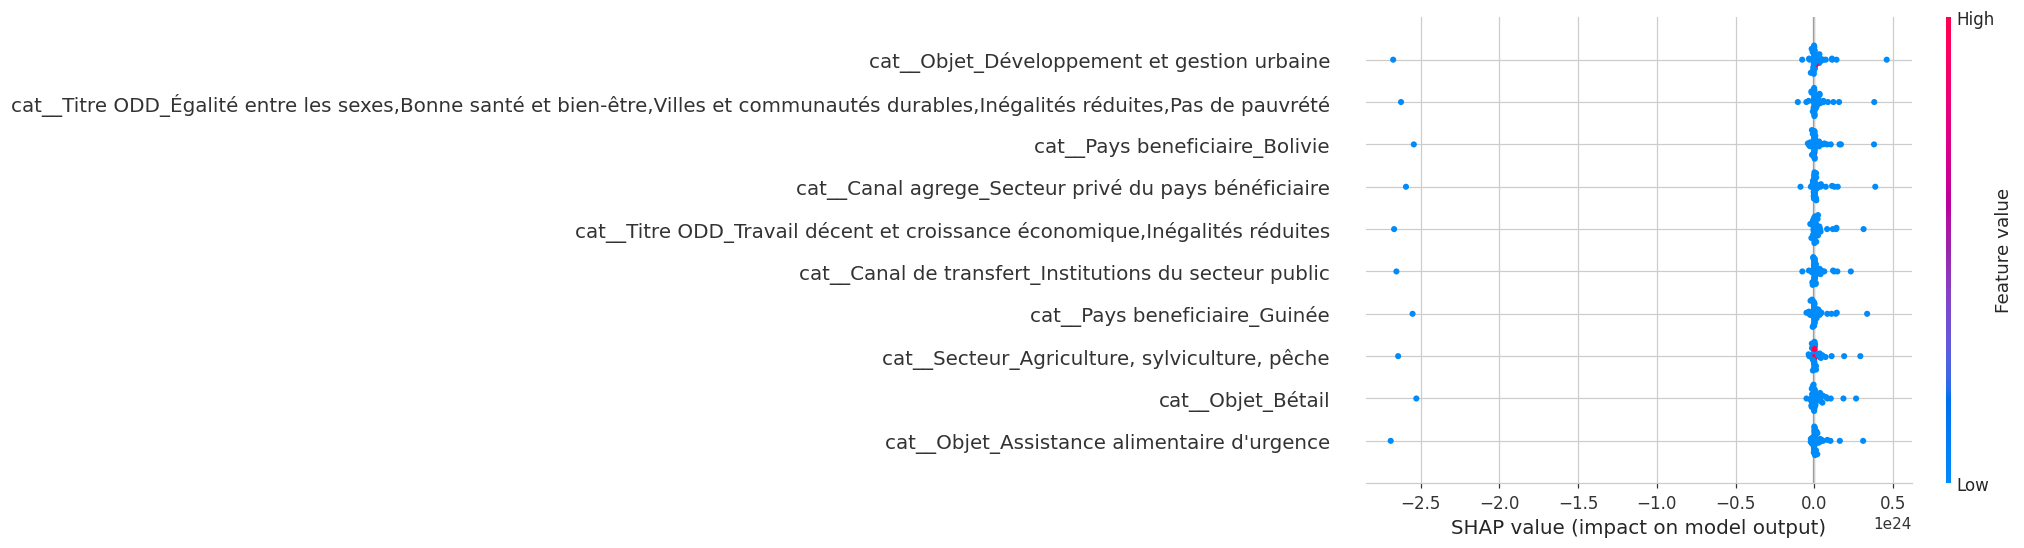

In [89]:
# Classe Elevé
shap_eleve = shap_values[:, :, 0]

shap.summary_plot(
    shap_eleve,
    X_shap_transformed,
    feature_names=feature_names,
    max_display=10
)

    
# Classe Faible
shap_faible = shap_values[:, :, 1]

shap.summary_plot(
    shap_faible,
    X_shap_transformed,
    feature_names=feature_names,
    max_display=10
)




In [90]:
# 3 classes: Elevé, Faible et Moyen
# SHAP > 0, pousse vers la classe
# SHAP < 0, éloigne de la classe
# rouge, valeur élevée / présence forte (comme il ya bcp de variables one-hot encodées, svt modalité présente(=1))
# bleu, valeur faible / absence

In [91]:
# Classe Elevé ( APD classique, gros projets sectoriels, climat/énergie, aide d'urgence/coordination, certains contextes géographiques
# Des projets énergétiques, climat ou reconstruction, ont des montants élevés.
    

In [92]:
# Classe Faible
# Le modèle associe Faible à projets techniques, coopération institutionnelle, projet académiques, interventions plus ciblées
# Ce sont souvent des tickets plus petits.


In [93]:
# Classe Moyen
# C'est la classe la plus ambiguë

In [94]:
# Comme la classe Moyen est floue, trop de variables one-hot, nous allons essayer CatBoostClassifier

In [95]:
!pip install catboost

In [96]:
# Préparation X et y
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Cible classification
target_col = "classe_financement"
X = df.drop(columns=[target_col, "Engagements (K EUR)", "log_engagements"], errors="ignore")
y = df[target_col]
# Encodage de la cible
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(label_encoder.classes_)

['Elevé' 'Faible' 'Moyen']


In [97]:
# Identification des colonnes catégorielles
cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
# On remplace les NA catégoriels
for col in cat_cols:
    X[col] = X[col].astype("string").fillna("Non renseigné")
# On remplace les NA numériques
num_cols = X.select_dtypes(include="number").columns.tolist()
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())
cat_features = [X.columns.get_loc(col) for col in cat_cols]

print("Nombre variables catégorielles :", len(cat_cols))
print("Nombre variables numériques :", len(num_cols))

Nombre variables catégorielles : 19
Nombre variables numériques : 14


In [98]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [99]:
# Modèle CatBoostClassifier
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=42,
    verbose=100
)
cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    use_best_model=True
)

0:	learn: 0.5801293	test: 0.5777415	best: 0.5777415 (0)	total: 174ms	remaining: 2m 19s
100:	learn: 0.6539051	test: 0.6636213	best: 0.6636213 (100)	total: 13.2s	remaining: 1m 31s
200:	learn: 0.6674989	test: 0.6770336	best: 0.6773415 (199)	total: 27.5s	remaining: 1m 21s
300:	learn: 0.6752032	test: 0.6796872	best: 0.6799097 (297)	total: 41.2s	remaining: 1m 8s
400:	learn: 0.6794818	test: 0.6818735	best: 0.6820752 (375)	total: 53s	remaining: 52.8s
500:	learn: 0.6835689	test: 0.6837501	best: 0.6840133 (499)	total: 1m 7s	remaining: 40.3s
600:	learn: 0.6871756	test: 0.6858761	best: 0.6858761 (600)	total: 1m 23s	remaining: 27.6s
700:	learn: 0.6902428	test: 0.6870821	best: 0.6873564 (672)	total: 1m 37s	remaining: 13.8s
799:	learn: 0.6932430	test: 0.6875046	best: 0.6881724 (755)	total: 1m 54s	remaining: 0us

bestTest = 0.6881723909
bestIteration = 755

Shrink model to first 756 iterations.


CatBoostClassifier(depth=6, eval_metric='TotalF1', iterations=800, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [100]:
# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import pandas as pd

y_pred = cat_model.predict(X_test).ravel()

print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1 weighted :", f1_score(y_test, y_pred, average="weighted"))
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

Accuracy : 0.6905409680480861
F1 weighted : 0.6881723908794389
              precision    recall  f1-score   support

       Elevé       0.79      0.78      0.78      5268
      Faible       0.66      0.75      0.70      5271
       Moyen       0.63      0.54      0.58      5266

    accuracy                           0.69     15805
   macro avg       0.69      0.69      0.69     15805
weighted avg       0.69      0.69      0.69     15805



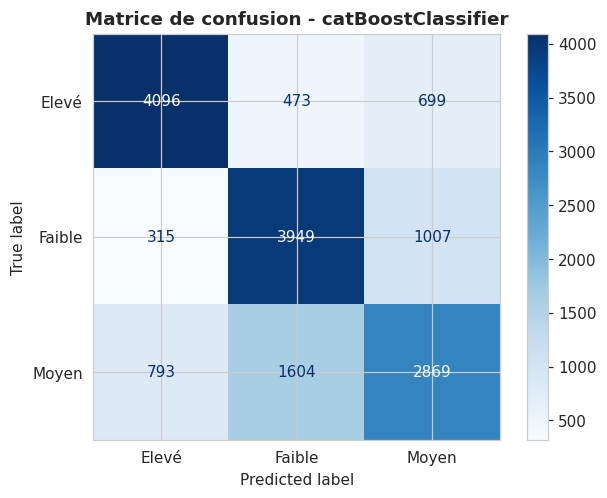

In [101]:
# Matrice de confusion
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matrice de confusion - catBoostClassifier")
plt.show()

In [102]:
# Changement de classification: classification binaire avec zone grise retirée
import numpy as  np
import pandas as pd

target_col = "Engagements (K EUR)"
# Seuils bas / haut
q_low = df[target_col].quantile(0.30)
q_high = df[target_col].quantile(0.70)
print("seuil faible 30% :", q_low)
print("seuil élevé 70% :", q_high)

# On retire la zone intermédiaire
df_classif = df[
    (df[target_col] <= q_low) |
    (df[target_col] >= q_high)
].copy()

# Nouvelle cible binaire
df_classif["classe_financement"] = np.where(
    df_classif[target_col] <= q_low,
    "Faible",
    "Elevé"
)
print(df_classif["classe_financement"].value_counts())
print(df_classif.shape)


seuil faible 30% : 6.485916569600001
seuil élevé 70% : 90.90528892399998
classe_financement
Elevé     23708
Faible    23708
Name: count, dtype: int64
(47416, 36)


In [103]:
# Préparation X et y
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Cible 
y = df_classif["classe_financement"]
X = df_classif.drop(
    columns=[
        "classe_financement",
        "Engagements (K EUR)",
        "log_engagements"
    ],
    errors="ignore"
)

# Encodage de la cible
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(label_encoder.classes_)

# Split stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

['Elevé' 'Faible']


In [104]:
# Préprocesseur
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import numpy as np

# Sécurisation
X = X.copy()

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = X.select_dtypes(include="number").columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype("object").where(X[col].notna(), "Non renseigné").astype(str)

for col in num_cols:
    X[col] = pd.to_numeric(X[col], errors="coerce")

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Non renseigné")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

In [105]:
# Pipelines modèles

models = {
    "RandomForest" : RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
    
    "XGBoost" : XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}

In [106]:
# Encodage de la cible
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(label_encoder.classes_)
print(pd.Series(y_encoded).value_counts())

# Evaluation par validation croisée
from sklearn.model_selection import cross_validate, StratifiedKFold
import pandas as pd

CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
results = []
for name, model in models.items() :
    pipe = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    
    scores = cross_validate(
        pipe,
        X,
        y_encoded,
        cv=cv,
        scoring=[
            "accuracy",
            "f1_weighted"
        ],
        n_jobs=-1
    )
    results.append({
        "Modèle" : name,
        "Accuracy moyen" : scores["test_accuracy"].mean(),
        "Accuracy std" : scores["test_accuracy"].std(),
        "F1 weighted" : scores["test_f1_weighted"].mean()
    })

benchmark = pd.DataFrame(results).sort_values(
    "Accuracy moyen",
    ascending=False
)
benchmark

['Elevé' 'Faible']
0    23708
1    23708
Name: count, dtype: int64


,Modèle,Accuracy moyen,Accuracy std,F1 weighted
0,RandomForest,0.878248,0.001629,0.878023
1,XGBoost,0.876118,0.002458,0.875940


In [107]:
# SHAP sur RandomForest binaire

import shap
X_sample = X.sample(300, random_state=42)

pipe = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])
pipe.fit(X, y_encoded)

X_sample_transformed = pipe.named_steps["preprocessing"].transform(X_sample)
feature_names = pipe.named_steps["preprocessing"].get_feature_names_out()
rf_model = pipe.named_steps["model"]
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(
    X_sample_transformed,
    check_additivity=False
)
print(label_encoder.classes_)

print(type(shap_values))
print(np.shape(shap_values))
print(X_sample_transformed.shape)
print(len(feature_names))

# ['Elevé', 'Faible'] donc Elevé = index 0
shap_eleve = shap_values[:, :, 0]

shap.summary_plot(
        shap_eleve,
        X_sample_transformed,
        feature_names=feature_names,
        max_display=15,
        show=False
)
plt.savefig(
    "figures/shap_classification_eleve.png",
    bbox_inches="tight", 
    dpi=300
)
plt.close()

['Elevé' 'Faible']
<class 'numpy.ndarray'>
(300, 2621, 2)
(300, 2621)
2621


In [108]:
# Pour la classe Faible
shap_faible = shap_values[:, :, 1]

shap.summary_plot(
        shap_faible,
        X_sample_transformed,
        feature_names=feature_names,
        max_display=15,
        show=False
)
plt.savefig(
    "figures/shap_classification_faible.png",
    bbox_inches="tight", 
    dpi=300
)
plt.close()

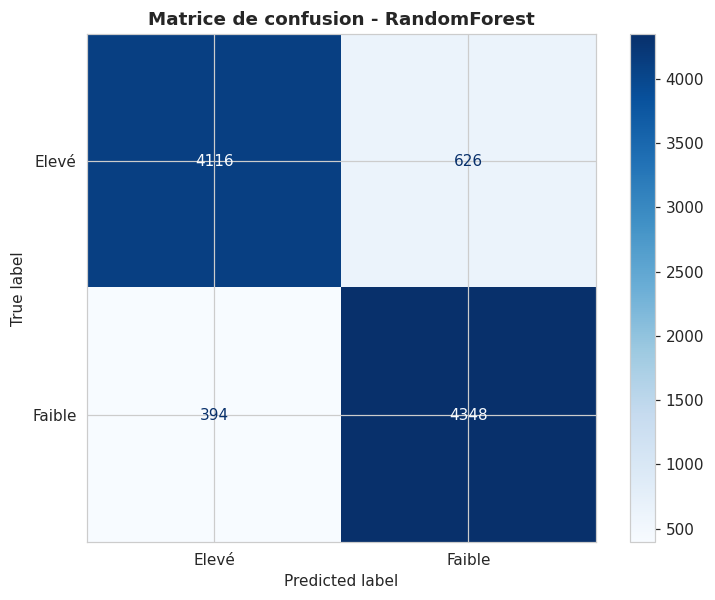

              precision    recall  f1-score   support

       Elevé       0.91      0.87      0.89      4742
      Faible       0.87      0.92      0.90      4742

    accuracy                           0.89      9484
   macro avg       0.89      0.89      0.89      9484
weighted avg       0.89      0.89      0.89      9484



In [124]:
# Matrice de confusion
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Sécurisation
X_train_safe = X_train.copy()
X_test_safe = X_test.copy()

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

for col in cat_cols:
    X_train_safe[col] = X_train_safe[col].astype("object").where(X_train_safe[col].notna(), "Non renseigné").astype(str)
    X_test_safe[col] = X_test_safe[col].astype("object").where(X_test_safe[col].notna(), "Non renseigné").astype(str)

for col in num_cols:
    X_train_safe[col] = pd.to_numeric(X_train_safe[col], errors="coerce")
    X_test_safe[col] = pd.to_numeric(X_test_safe[col], errors="coerce")


# Prédictions
rf_pipe.fit(X_train_safe, y_train)
y_pred_rf = rf_pipe.predict(X_test_safe)

# Matrice
cm = confusion_matrix(y_test, y_pred_rf)

#Affichage
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(
    cmap="Blues",
    ax=ax,
    values_format="d"
)
plt.title("Matrice de confusion - RandomForest")

fig.savefig(
    "figures/confusion_matrix_rf.png",
    bbox_inches="tight", 
    dpi=300
)
plt.show()
plt.close(fig)

# Rapport
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_
))

In [125]:
import joblib
from joblib import dump

dump(rf_pipe, "modele_classification_rf.pkl")
dump(best_rf, "modele_regression_rf.pkl")
dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [126]:
dump(rf_pipe, "modele_classification_rf.pkl")
print("RF Classification OK")

dump(best_rf, "modele_regression_rf.pkl")
print("RF Régression OK")

dump(label_encoder, "label_encoder.pkl")
print("Label Encoder OK")

import os
[f for f in os.listdir() if f.endswith(".pkl")]

      

RF Classification OK
RF Régression OK
Label Encoder OK


['modele_regression_rf.pkl',
 'label_encoder.pkl',
 'modele_classification_rf.pkl']

In [116]:
import os
os.listdir("figures")

['shap_regression.png',
 'confusion_matrix_rf.png',
 'top20_variables_rf.png',
 'shap_classification_eleve.png',
 'shap_classification_faible.png']

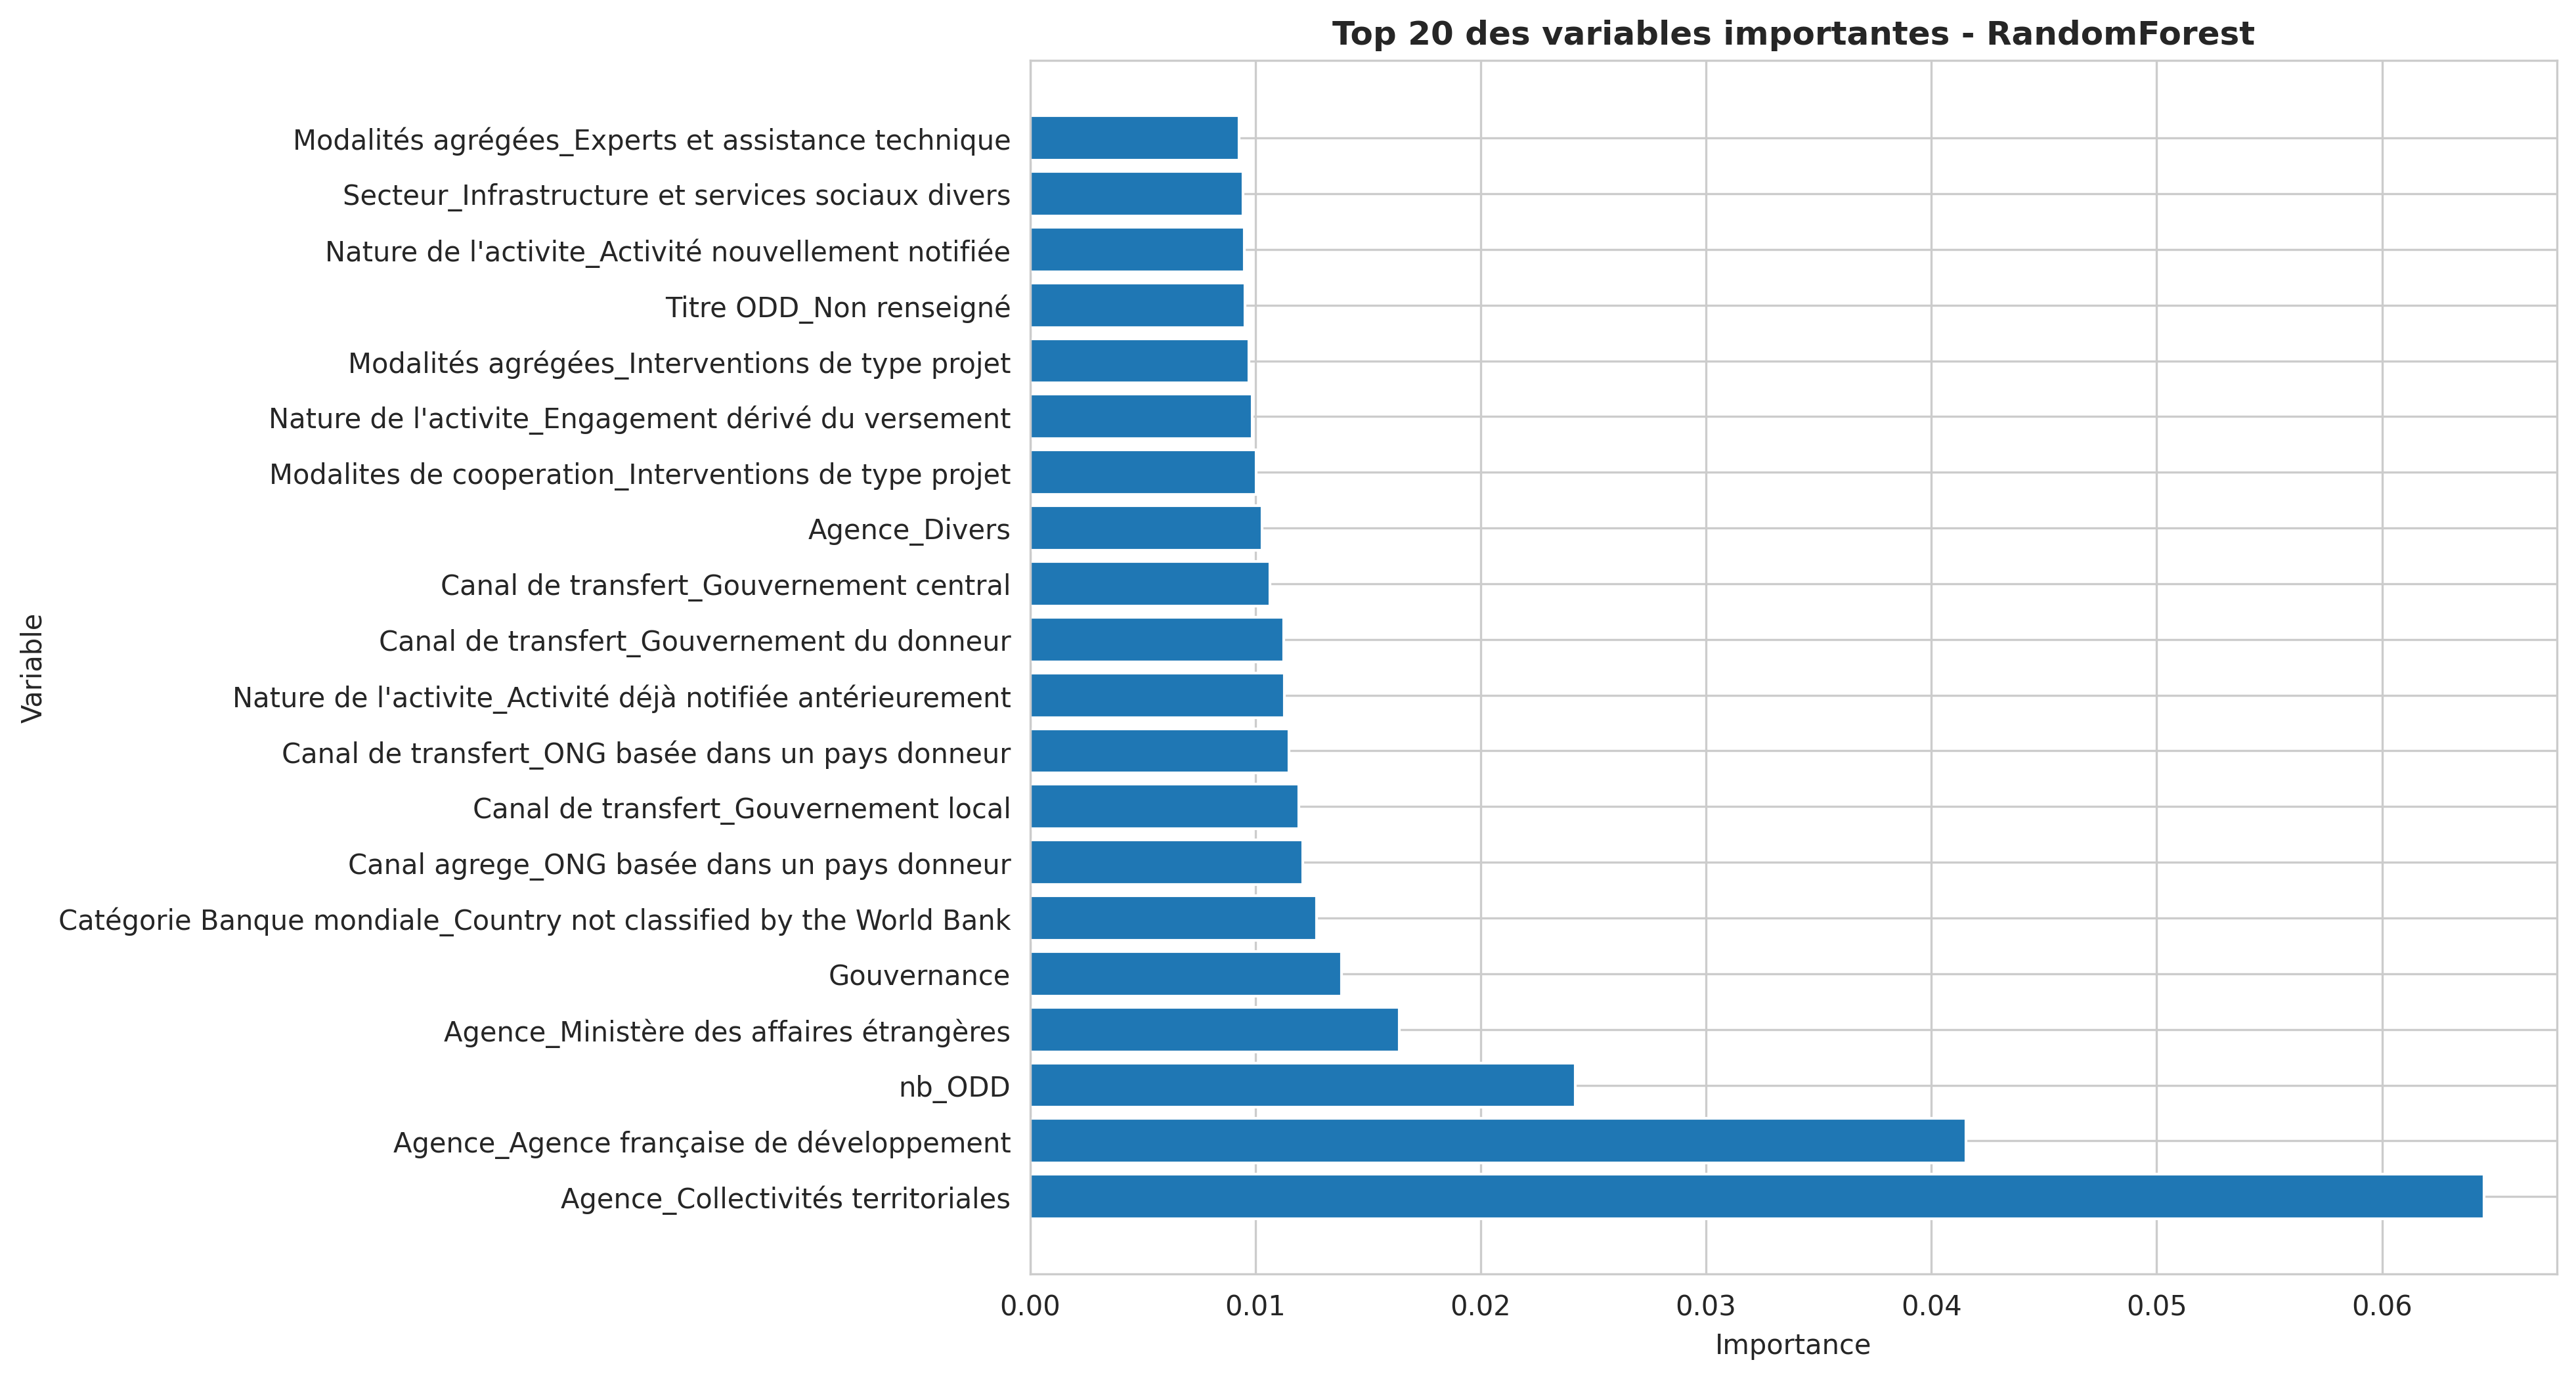

In [122]:
from PIL import Image
Image.open("figures/top20_variables_rf.png")


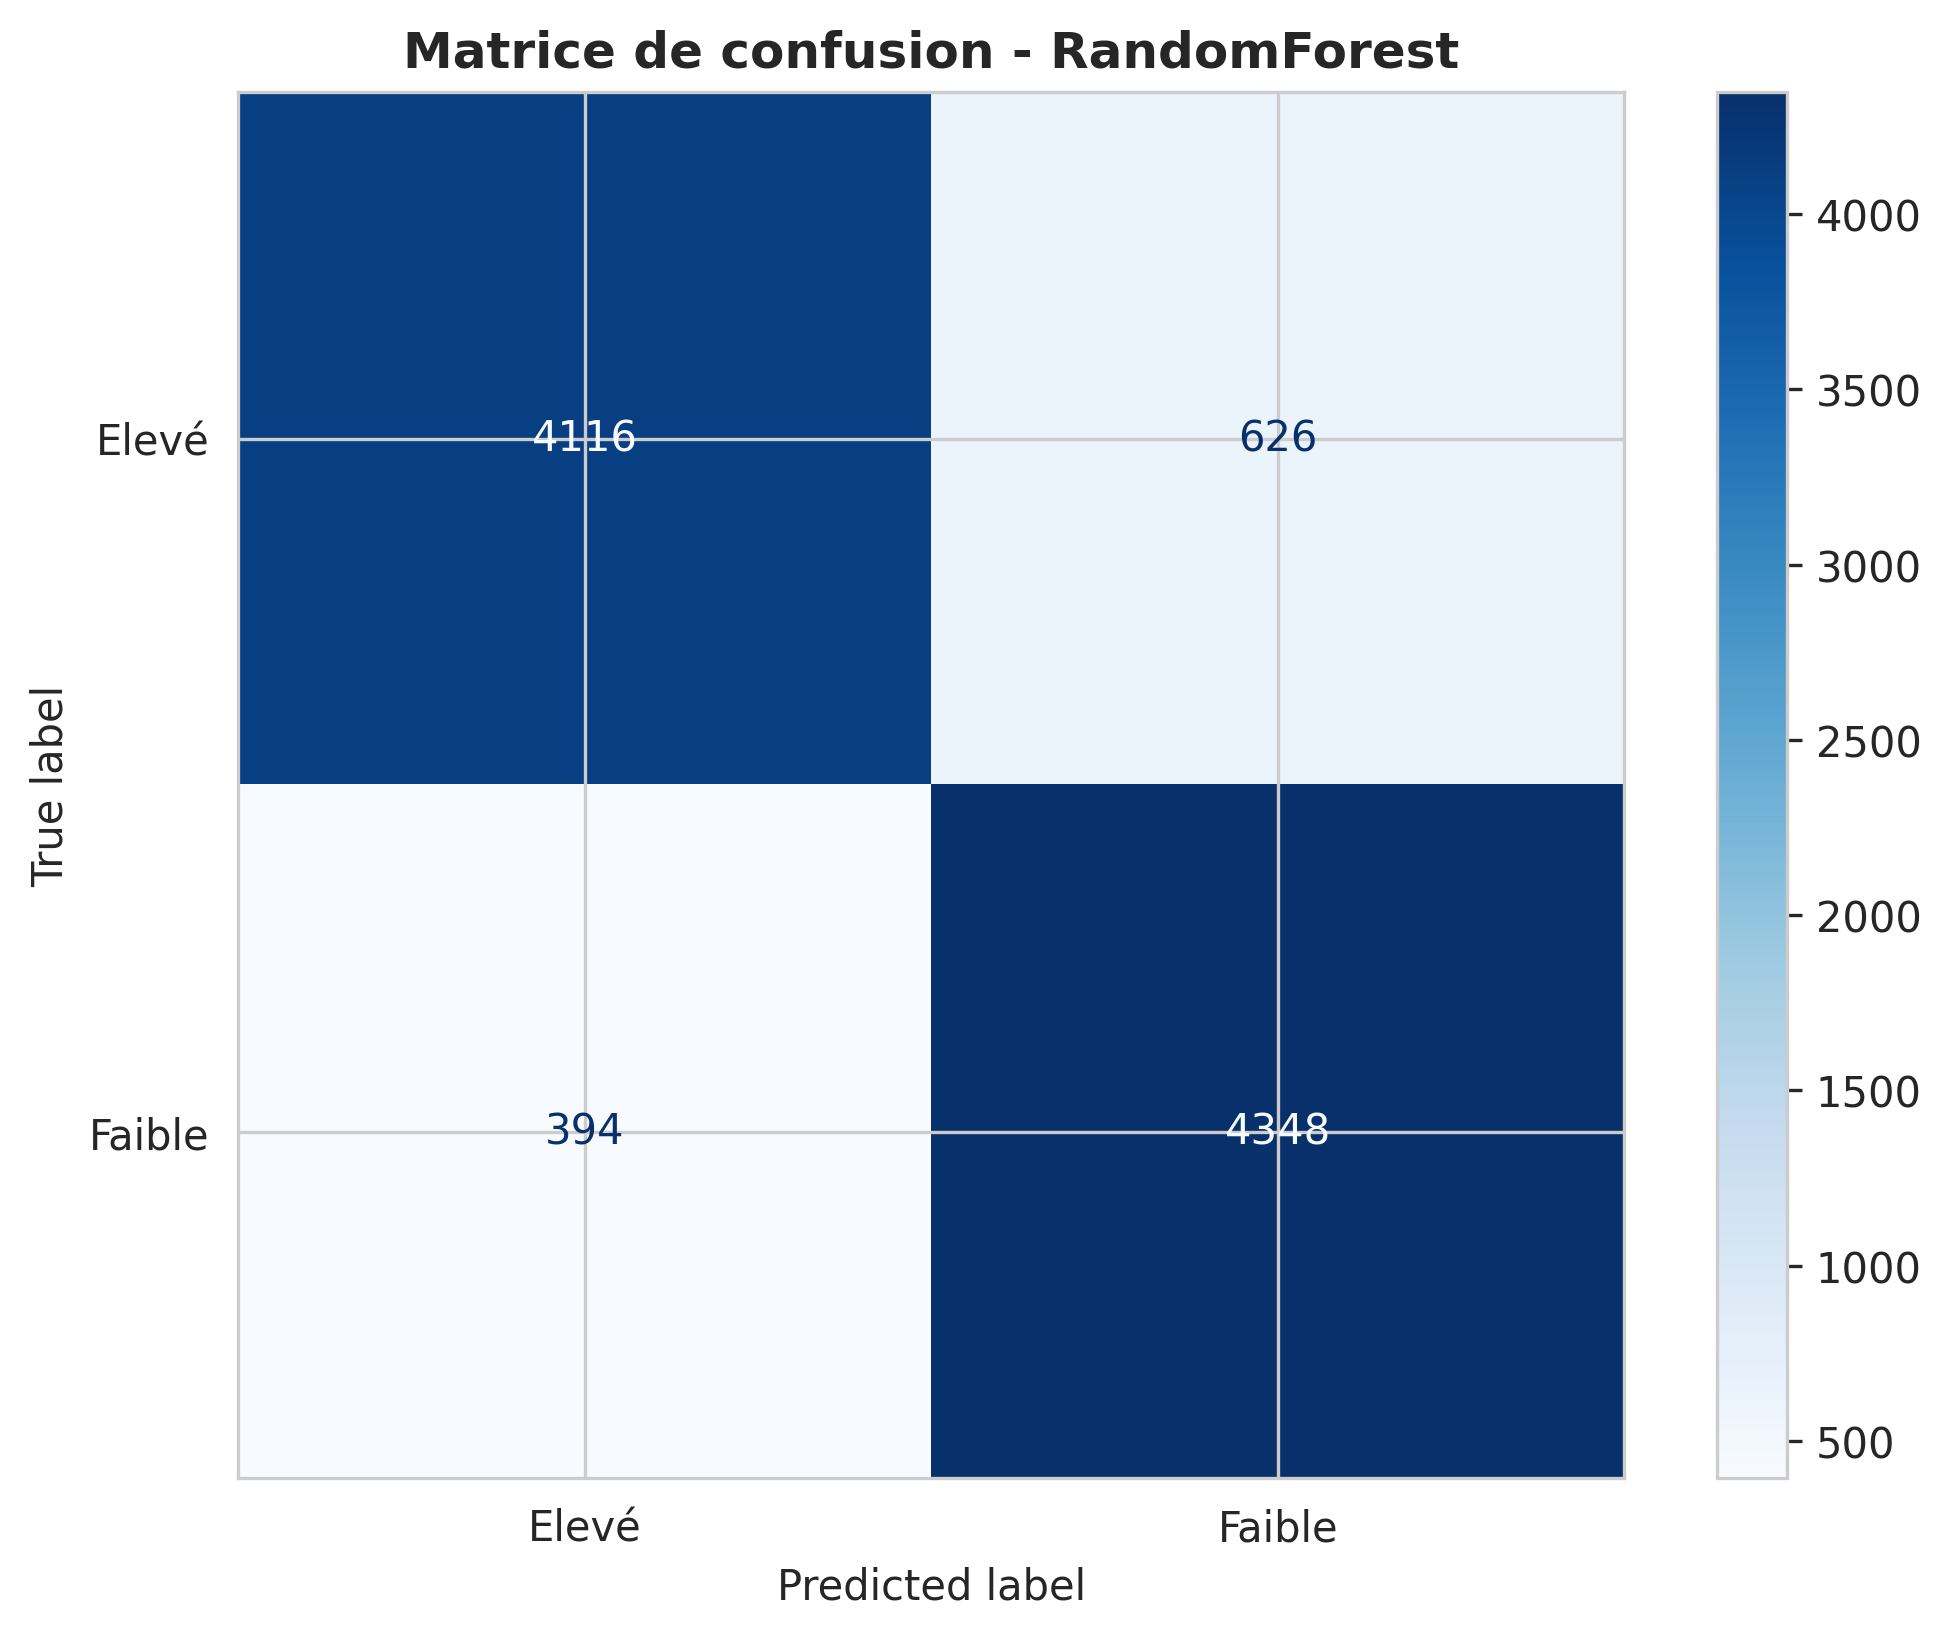

In [123]:
Image.open("figures/confusion_matrix_rf.png")